# 06 — BERTopic Pipeline untuk BYOND by BSI

Topic modeling temporal terhadap keluhan pengguna **BYOND by BSI** menggunakan **BERTopic** dengan **IndoBERT** embeddings, dilanjutkan dengan validasi cosine similarity (Section 9) dan uji tren Mann-Kendall (Section 10).

## Pipeline Overview

| Section | Tahap | Output utama |
|---------|-------|--------------|
| 0 | Setup (imports + autoreload) | — |
| 1 | Load data + generate IndoBERT embeddings (cached) | `data/embeddings/byond_embeddings.npy` |
| 2 | Sensitivity analysis 3×3 grid (UMAP × HDBSCAN) | Grid table |
| 3 | Pick winner via c_v coherence | Winner params |
| 4 | Validate winner with c_npmi | Coherence comparison |
| 5 | Final Phase A model | Locked config |
| 6 | Topic inspection (Phase A output) | Top words + rep docs |
| 7 | Phase B (stopword refinement) + Phase C (manual merge) | `data/models/byond_phase_c/` (TBD topics) |
| 8 | DTM monthly analysis | Frequency + proportion plots, 3 summary tables |
| 9 | Cosine similarity D1 (embedding) + D2 (c-TF-IDF) | 4 plots, comparison table |
| 9.5 | Threshold sensitivity check | Histogram + reklasifikasi pattern |
| 10 | Mann-Kendall + Sen's slope + FDR-BH | 4 plots, 3 tables |
| 10.5 | T11 numerical edge case fix | Practically stable flag |

## Output Locations

- **Models:** `data/models/byond_phase_c/` (safetensors)
- **Tabel:** `outputs/tables/byond_*.csv`
- **Figures:** `outputs/figures/byond/*.png`
- **DTM intermediate:** `data/processed/byond_topics_over_time.pkl`

## Catatan untuk Kernel Reload

Section 8 dan setelahnya bisa dijalankan dari fresh kernel (tanpa run Section 0-7 dulu) lewat **Section 8.0 — Kernel Reload Sequence**. Berguna kalau lagi iterate di tahap analysis tanpa harus retrain BERTopic.

## Section 0 — Setup

### 0.1 Imports + autoreload

`autoreload 2` memastikan edit pada modul `utils/` ke-pick up tanpa restart kernel. Wajib untuk workflow modular.

In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

In [4]:
from pathlib import Path

from utils.embedding import load_indobert_model, generate_embeddings

## Section 1 — Load Data + Generate Embeddings

**Heads up:** First run akan generate embeddings dari scratch (~40-60 menit untuk BYOND di CPU). Subsequent runs akan load dari cache — instant.

### 1.1 Load preprocessed data

In [5]:
df_byond = pd.read_csv('data/processed/byond_bertopic.csv')

print(f"Shape: {df_byond.shape}")
print(f"Columns: {df_byond.columns.tolist()}")
df_byond.head()

Shape: (19393, 6)
Columns: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating']


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,2c29f9a1-67dc-4013-9e6c-8654fc55400f,masukkan data sudah benar tapi dianggap salah,1,1,2024-11-09 03:27:30,1
1,cbb3030c-ae6c-4618-ae19-89691803eb40,ini kenapa aplikasi force close terus tiba,1,1,2024-11-09 03:34:29,1
2,be2133d7-23be-4623-9292-1cd732dc2aae,belum bisa masuk selalu dikatakan data diri ti...,1,1,2024-11-09 04:52:16,1
3,f98d6d48-7367-48ca-a9d1-8ecde01b2211,mohon ditambahkan fitur tarik tunai tanpa kart...,1,1,2024-11-09 13:15:25,1
4,43a5e0a5-99a8-4204-a1b6-a483019f71dd,aplikasi bagus namun aneh baru kali ini mobile...,1,1,2024-11-09 14:45:21,1


### 1.2 Sanity check: nulls + relative_month coverage

In [6]:
critical_cols = ['review_text_cleaned', 'relative_month', 'relative_week']
print("Null counts:")
print(df_byond[critical_cols].isnull().sum())

print("\nRelative month distribution:")
print(df_byond['relative_month'].value_counts().sort_index())

Null counts:
review_text_cleaned    0
relative_month         0
relative_week          0
dtype: int64

Relative month distribution:
relative_month
1      487
2     2040
3     1962
4     6284
5      921
6      543
7     1108
8      881
9     1125
10    2552
11     807
12     683
Name: count, dtype: int64


### 🟡 Pre-flight finding: Distribusi M4 mega-spike (KEEP-DEV)

Distribusi `relative_month` BYOND **sangat skewed** dibanding wondr — worth flagged sebelum lanjut analysis.

**Statistik distribusi BYOND:**

| Metric | Wondr | BYOND |
|--------|-------|-------|
| Total docs | 8,982 | 19,393 |
| Min count per bulan | ~700 (M12) | 487 (M1) |
| Max count per bulan | ~1,200 (M5) | **6,284 (M4)** |
| Ratio max/min | ~3-4x | **~12.9x** |
| Spike utama | M5 (~3x avg) | M4 (~3.9x avg) |
| Spike sekunder | — | M10 (2,552) |

**Hipotesis kerja (untuk validasi di Section 8 + 10):**

1. **Major incident di M4 post-launch (≈ Februari 2025)** — analog dengan M5 outage signature wondr. BYOND launch 9 November 2024 → M4 = sekitar 9 Februari – 8 Maret 2025. Worth investigation untuk identifikasi event spesifik.

2. **DTM proportion plot bakal lebih informatif daripada frequency plot** — frequency bakal didominasi M4 spike, proportion (share normalized per month) yang bakal reveal real pattern per topic.

3. **M4 mega-spike = potential leverage point untuk Mann-Kendall** (Section 10) — slope estimate sensitive ke outlier extreme. Tidak require special handling, tapi worth flagged untuk interpretasi.

4. **M11-M12 late-period signal thin** (~683-807 docs/bulan) — limitation untuk late-emerging topic detection. Perlu di-flag sebagai methodology limitation di BAB 4.

**Comparative angle untuk BAB 4:**
- Wondr: outage M5 spike ~3x avg, ratio max/min moderate
- BYOND: outage M4 spike ~3.9x avg, ratio max/min extreme
- → BYOND mengalami disruption yang **lebih severe relatively**, atau **base activity bulan-bulan lain lebih rendah** (early adoption thinner). Diferensiasi ini bisa di-validate cross-app di analisis comparative.

**Flag status:** 🟡 KEEP-DEV — finding ini **dokumentasi-worthy** untuk BAB 4. Jangan delete saat cleanup notebook clean.

### 1.3 Extract texts as list

BERTopic expects list of strings, bukan pandas Series. Extract sekali, reuse throughout.

In [7]:
docs_byond = df_byond['review_text_cleaned'].tolist()

print(f"Total docs: {len(docs_byond)}")
print(f"Sample doc: {docs_byond[0][:200]}")

Total docs: 19393
Sample doc: masukkan data sudah benar tapi dianggap salah


### 1.4 Load IndoBERT model

In [8]:
model = load_indobert_model()
print(f"Model loaded: {type(model).__name__}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded: SentenceTransformer


### 1.5 Generate embeddings (or load from cache)

Kalau preprocessing data berubah, manual delete cache file sebelum re-run:
```
del data\embeddings\byond_embeddings.npy
```

In [9]:
embedding_cache_path = Path('data/embeddings/byond_embeddings.npy')
embedding_cache_path.parent.mkdir(parents=True, exist_ok=True)

embeddings_byond = generate_embeddings(
    texts=docs_byond,
    model=model,
    cache_path=embedding_cache_path,
)

print(f"\nEmbedding shape: {embeddings_byond.shape}")
print(f"Dtype: {embeddings_byond.dtype}")
print(f"Cache file size: {embedding_cache_path.stat().st_size / (1024**2):.1f} MB")

[cache miss] Generating embeddings for 19393 texts...


Batches:   0%|          | 0/607 [00:00<?, ?it/s]

[cache miss] Saved to data\embeddings\byond_embeddings.npy, shape: (19393, 768)

Embedding shape: (19393, 768)
Dtype: float32
Cache file size: 56.8 MB


## Section 2 — Sensitivity Analysis (3×3 Grid)

Cari kombinasi `(n_neighbors, min_cluster_size)` terbaik via grid search 3×3 = 9 fits. Embedding di-cache, jadi yang re-run cuma UMAP + HDBSCAN + c-TF-IDF (~20-30 menit total).

**Phase A:** Sastrawi stopwords only (~123 kata). Custom domain stopwords ditambahkan di Phase B (Section 7).

**Methodological note:** `min_df=2` (bukan default 10) — adjustment karena BERTopic apply CountVectorizer di topic level, bukan document level. Dengan target 5-15 topics, `min_df=10` jadi infeasible.

### 2.1 Imports + grid setup

In [10]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

from utils.clustering import build_umap_model, build_hdbscan_model
from utils.evaluation import compute_coherence
from utils.stopwords import get_sastrawi_stopwords

In [13]:
# Grid search space v2 (BYOND-specific, adjusted from initial v1)
# v1 finding: n_neighbors=25 caused over-smoothing (n_topics ≤ 2 → CountVectorizer ValueError)
# v1 finding: min_cluster_size=30 caused fragmentation (40 topics, overshoots 15-30 filter)
# v2 adjustment: drop nn=25 + mcs=30, add nn=20 + mcs=75 untuk denser sampling sweet spot.
n_neighbors_grid = [10, 15, 20]
min_cluster_size_grid = [50, 75, 100]

# c-TF-IDF vectorizer (Phase A: Sastrawi stopwords only, sama dengan wondr)
sastrawi_stopwords = get_sastrawi_stopwords()

vectorizer_model = CountVectorizer(
    stop_words=sastrawi_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

print(f"Grid combinations (v2): {len(n_neighbors_grid) * len(min_cluster_size_grid)}")
print(f"  n_neighbors: {n_neighbors_grid}")
print(f"  min_cluster_size: {min_cluster_size_grid}")
print(f"Sastrawi stopwords: {len(sastrawi_stopwords)} words")

Grid combinations (v2): 9
  n_neighbors: [10, 15, 20]
  min_cluster_size: [50, 75, 100]
Sastrawi stopwords: 123 words


### 2.2 Run grid search

Untuk tiap kombinasi: build UMAP + HDBSCAN, fit BERTopic dengan cached embeddings, compute c_v coherence.

In [15]:
# 🟢 DELETE BEFORE FINAL COMMIT — try/except workaround untuk handle collapse cases
# Background: BYOND grid topology lebih chaotic dari wondr; beberapa kombinasi UMAP+HDBSCAN
# collapse ke n_topics ≤ 2 yang trigger CountVectorizer ValueError. Skip kombinasi gagal.

results = []
errors = []

for nn in n_neighbors_grid:
    for mcs in min_cluster_size_grid:
        print(f"\n--- Fitting: n_neighbors={nn}, min_cluster_size={mcs} ---")
        
        try:
            umap_model = build_umap_model(n_neighbors=nn)
            hdbscan_model = build_hdbscan_model(min_cluster_size=mcs)
            
            topic_model = BERTopic(
                embedding_model=model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                vectorizer_model=vectorizer_model,
                top_n_words=10,
                verbose=False,
            )
            
            topics, _ = topic_model.fit_transform(docs_byond, embeddings=embeddings_byond)
            
            n_topics = len(set(topics)) - (1 if -1 in topics else 0)
            c_v = compute_coherence(topic_model, docs_byond, coherence='c_v')
            
            print(f"  -> n_topics: {n_topics}, c_v: {c_v:.4f}")
            
            results.append({
                'n_neighbors': nn,
                'min_cluster_size': mcs,
                'n_topics': n_topics,
                'c_v': c_v,
            })
        except ValueError as e:
            print(f"  -> SKIPPED: {str(e)[:80]}")
            errors.append({
                'n_neighbors': nn,
                'min_cluster_size': mcs,
                'error': str(e)[:80],
            })

results_df = pd.DataFrame(results)
print("\n=== Grid Search Results ===")
print(results_df.to_string(index=False))

if errors:
    errors_df = pd.DataFrame(errors)
    print(f"\n=== Skipped combinations ({len(errors)}) — collapsed to ≤2 topics ===")
    print(errors_df.to_string(index=False))


--- Fitting: n_neighbors=10, min_cluster_size=50 ---
  -> n_topics: 37, c_v: 0.6853

--- Fitting: n_neighbors=10, min_cluster_size=75 ---
  -> n_topics: 13, c_v: 0.6833

--- Fitting: n_neighbors=10, min_cluster_size=100 ---
  -> n_topics: 2, c_v: 0.5099

--- Fitting: n_neighbors=15, min_cluster_size=50 ---
  -> SKIPPED: max_df corresponds to < documents than min_df

--- Fitting: n_neighbors=15, min_cluster_size=75 ---
  -> n_topics: 11, c_v: 0.7191

--- Fitting: n_neighbors=15, min_cluster_size=100 ---
  -> n_topics: 2, c_v: 0.6297

--- Fitting: n_neighbors=20, min_cluster_size=50 ---
  -> n_topics: 2, c_v: 0.6465

--- Fitting: n_neighbors=20, min_cluster_size=75 ---
  -> SKIPPED: max_df corresponds to < documents than min_df

--- Fitting: n_neighbors=20, min_cluster_size=100 ---
  -> n_topics: 2, c_v: 0.6755

=== Grid Search Results ===
 n_neighbors  min_cluster_size  n_topics      c_v
          10                50        37 0.685303
          10                75        13 0.683341

In [14]:
results = []

for nn in n_neighbors_grid:
    for mcs in min_cluster_size_grid:
        print(f"\n--- Fitting: n_neighbors={nn}, min_cluster_size={mcs} ---")
        
        umap_model = build_umap_model(n_neighbors=nn)
        hdbscan_model = build_hdbscan_model(min_cluster_size=mcs)
        
        topic_model = BERTopic(
            embedding_model=model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_model,
            top_n_words=10,
            verbose=False,
        )
        
        topics, _ = topic_model.fit_transform(docs_byond, embeddings=embeddings_byond)
        
        n_topics = len(set(topics)) - (1 if -1 in topics else 0)
        c_v = compute_coherence(topic_model, docs_byond, coherence='c_v')
        
        print(f"  -> n_topics: {n_topics}, c_v: {c_v:.4f}")
        
        results.append({
            'n_neighbors': nn,
            'min_cluster_size': mcs,
            'n_topics': n_topics,
            'c_v': c_v,
        })

results_df = pd.DataFrame(results)
print("\n=== Grid Search Results ===")
print(results_df.to_string(index=False))


--- Fitting: n_neighbors=10, min_cluster_size=50 ---
  -> n_topics: 37, c_v: 0.6853

--- Fitting: n_neighbors=10, min_cluster_size=75 ---
  -> n_topics: 13, c_v: 0.6833

--- Fitting: n_neighbors=10, min_cluster_size=100 ---
  -> n_topics: 2, c_v: 0.5099

--- Fitting: n_neighbors=15, min_cluster_size=50 ---


ValueError: max_df corresponds to < documents than min_df

## Section 3 — Pick Winner via c_v

Filter grid hasil dengan target topic count 15-30, lalu pilih c_v tertinggi.

**Hasil:** 3 kombinasi pass filter. Winner = `n_neighbors=15, min_cluster_size=60` dengan **c_v=TBD** (15 topics).

In [16]:
# 🟡 KEEP-DEV — modified from notebook 05 untuk handle BYOND empty-filter case
# BYOND grid hasil chaotic — tidak ada kombinasi yang lolos filter strict 15-30 topics.
# Manual override winner berdasarkan diskusi: Option B (n_neighbors=15, min_cluster_size=60).
# Justifikasi: c_v=0.6892 tertinggi di antara kombinasi dekat filter; 14 topics off-by-1
# dari minimum filter 15, acceptable trade-off.

# Display all results sorted by c_v
print("All grid results (sorted by c_v desc):")
print(results_df.sort_values('c_v', ascending=False).to_string(index=False))
print()

# Apply filter (for documentation)
filtered = results_df[(results_df['n_topics'] >= 15) & (results_df['n_topics'] <= 30)]
print(f"Combinations passing strict filter (15-30 topics): {len(filtered)}")
if len(filtered) > 0:
    print(filtered.to_string(index=False))
else:
    print("(none — see relaxation justification below)")

# Manual winner override based on Option B decision
WINNER_N_NEIGHBORS = 15
WINNER_MIN_CLUSTER_SIZE = 60

# Verify the manual winner exists in results
winner_row = results_df[
    (results_df['n_neighbors'] == WINNER_N_NEIGHBORS) &
    (results_df['min_cluster_size'] == WINNER_MIN_CLUSTER_SIZE)
]
assert len(winner_row) == 1, f"Winner combo not in results_df!"
winner = winner_row.iloc[0]

print(f"\n=== WINNER (manual override, see justification) ===")
print(f"n_neighbors:      {int(winner['n_neighbors'])}")
print(f"min_cluster_size: {int(winner['min_cluster_size'])}")
print(f"n_topics:         {int(winner['n_topics'])}")
print(f"c_v:              {winner['c_v']:.4f}")
print()
print("Justifikasi filter relaxation (untuk BAB 3):")
print("- Filter strict 15-30 topics: tidak ada kombinasi yang lolos")
print("- (15, 60) dengan 14 topics: off-by-1 dari minimum filter")
print("- c_v=0.6892 tertinggi di antara kandidat dekat filter")
print("- Topic count 14 konsisten dengan wondr Phase C (13 topics)")

best_n_neighbors = int(winner['n_neighbors'])
best_min_cluster_size = int(winner['min_cluster_size'])

All grid results (sorted by c_v desc):
 n_neighbors  min_cluster_size  n_topics      c_v
          15                75        11 0.719076
          10                50        37 0.685303
          10                75        13 0.683341
          20               100         2 0.675541
          20                50         2 0.646488
          15               100         2 0.629730
          10               100         2 0.509857

Combinations passing strict filter (15-30 topics): 0
(none — see relaxation justification below)


AssertionError: Winner combo not in results_df!

In [17]:
# Manual winner override — (15, 60) dari grid v1
# Grid v2 gak include mcs=60, jadi set manual berdasarkan grid v1 finding
best_n_neighbors = 15
best_min_cluster_size = 60

print(f"Winner manual override: n_neighbors={best_n_neighbors}, min_cluster_size={best_min_cluster_size}")
print("Phase A topic count + coherence akan di-recompute di Section 4 (validate).")
print()
print("Justifikasi (untuk BAB 3):")
print("- Grid v1 dan v2 dijalankan; kombinasi (15, 60) probed di v1")
print("- Filter strict 15-30 topics: tidak ada kombinasi yang lolos")
print("- (15, 60) dengan 14 topics: off-by-1 dari minimum filter, c_v=0.6892")
print("- Topic count 14 konsisten dengan wondr Phase C (13 topics)")

Winner manual override: n_neighbors=15, min_cluster_size=60
Phase A topic count + coherence akan di-recompute di Section 4 (validate).

Justifikasi (untuk BAB 3):
- Grid v1 dan v2 dijalankan; kombinasi (15, 60) probed di v1
- Filter strict 15-30 topics: tidak ada kombinasi yang lolos
- (15, 60) dengan 14 topics: off-by-1 dari minimum filter, c_v=0.6892
- Topic count 14 konsisten dengan wondr Phase C (13 topics)


In [ ]:
# Apply topic count filter (15-30 topics target per methodology)
filtered = results_df[(results_df['n_topics'] >= 15) & (results_df['n_topics'] <= 30)]

print("Combinations passing filter (15 <= n_topics <= 30):")
print(filtered.to_string(index=False))

# Pick winner: highest c_v from filtered
winner = filtered.loc[filtered['c_v'].idxmax()]

print(f"\n=== WINNER ===")
print(f"n_neighbors:      {int(winner['n_neighbors'])}")
print(f"min_cluster_size: {int(winner['min_cluster_size'])}")
print(f"n_topics:         {int(winner['n_topics'])}")
print(f"c_v:              {winner['c_v']:.4f}")

best_n_neighbors = int(winner['n_neighbors'])
best_min_cluster_size = int(winner['min_cluster_size'])

## Section 4 — Validate Winner with c_npmi

Re-fit BERTopic dengan winner params, compute kedua metrik (c_v + c_npmi) untuk validasi.

**Why this matters:** c_v primary metric (per Röder et al., 2015). c_npmi secondary — kalau keduanya agree, confidence lebih kuat. Kalau disagree, prefer c_v winner dan diskusikan disagreement sebagai finding.

**Heads up:** Re-fit ~30-60 detik (single fit, bukan full grid).

In [18]:
from utils.evaluation import compute_coherence_both

print(f"Re-fitting BERTopic with n_neighbors={best_n_neighbors}, "
      f"min_cluster_size={best_min_cluster_size}...")

umap_winner = build_umap_model(n_neighbors=best_n_neighbors)
hdbscan_winner = build_hdbscan_model(min_cluster_size=best_min_cluster_size)

topic_model_winner = BERTopic(
    embedding_model=model,
    umap_model=umap_winner,
    hdbscan_model=hdbscan_winner,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=False,
)

topics_winner, _ = topic_model_winner.fit_transform(
    docs_byond, embeddings=embeddings_byond
)

# Compute both coherence scores
scores = compute_coherence_both(topic_model_winner, docs_byond)

n_topics_winner = len(set(topics_winner)) - (1 if -1 in topics_winner else 0)

print(f"\n=== Validation Results ===")
print(f"n_topics: {n_topics_winner}")
print(f"c_v:      {scores['c_v']:.4f}  (primary)")
print(f"c_npmi:   {scores['c_npmi']:.4f}  (validation)")

Re-fitting BERTopic with n_neighbors=15, min_cluster_size=60...

=== Validation Results ===
n_topics: 14
c_v:      0.6892  (primary)
c_npmi:   0.1574  (validation)


### 4.1 Interpretation

| Metric | Score | Range typical | Verdict |
|---|---|---|---|
| c_v | 0.6892 | 0.65-0.75 = good | ✅ Good topic quality |
| c_npmi | 0.1574 | 0.15-0.25 = good | ✅ Positive co-occurrence (lower edge of "Good") |

**Both metrics agree.** Winner combination `(n_neighbors=15, min_cluster_size=60)` produces 14 coherent topics. Proceed ke Phase B refinement.

**Comparative dengan wondr Phase A:**
- BYOND: c_v=0.6892, c_npmi=0.1574 (14 topics)
- Wondr: c_v=0.7055, c_npmi=0.1723 (15 topics)

BYOND coherence sedikit lebih rendah (Δc_v=-0.0163, Δc_npmi=-0.0149) — kemungkinan karena corpus 2x lebih besar dan distribusi topic lebih heterogen (M4 mega-spike). Tetap di "Good" tier, gak alarming.

**Filter relaxation note (untuk BAB 3):** Topic count 14 marginally off (off-by-1) dari filter minimum 15. Diterima karena: (a) c_v=0.6892 di "Good" tier, (b) konsistensi dengan wondr Phase C (13 topics) untuk comparative analysis, (c) tidak ada kombinasi grid yang lolos filter strict (lihat Section 3 grid results).

## Section 5 — Final Phase A Model

Berdasarkan grid search (Section 2) dan validasi metrik (Section 3-4), parameter winner adalah `n_neighbors=15` dan `min_cluster_size=60` → **15 topics, c_v=TBD, c_npmi=TBD**. Kedua metrik agree.

Model `topic_model_winner` (sudah di-fit di Section 4) digunakan langsung sebagai Phase A final — no re-fit needed karena UMAP pakai `random_state=42` (deterministic). Cell berikutnya men-dokumentasikan konfigurasi final untuk reproducibility.

In [19]:
import json

phase_a_config = {
    "embedding_model": "indobenchmark/indobert-base-p2",
    "embedding_dim": 768,
    "umap": {
        "n_neighbors": best_n_neighbors,        # 15
        "n_components": 5,
        "min_dist": 0.0,
        "metric": "cosine",
        "random_state": 42,
    },
    "hdbscan": {
        "min_cluster_size": best_min_cluster_size,  # 60
        "metric": "euclidean",
        "cluster_selection_method": "eom",
        "prediction_data": True,
    },
    "vectorizer": {
        "stop_words": "sastrawi (123 words)",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
    },
    "results": {
        "n_topics": len(topic_model_winner.get_topic_info()) - 1,
        "c_v": round(scores['c_v'], 4),
        "c_npmi": round(scores['c_npmi'], 4),
    },
}

print("=" * 60)
print("PHASE A FINAL MODEL — LOCKED CONFIGURATION (BYOND)")
print("=" * 60)
print(json.dumps(phase_a_config, indent=2, default=str))
print("=" * 60)
print(f"\n✓ Model `topic_model_winner` ready untuk Section 6 (inspection)")

PHASE A FINAL MODEL — LOCKED CONFIGURATION (BYOND)
{
  "embedding_model": "indobenchmark/indobert-base-p2",
  "embedding_dim": 768,
  "umap": {
    "n_neighbors": 15,
    "n_components": 5,
    "min_dist": 0.0,
    "metric": "cosine",
    "random_state": 42
  },
  "hdbscan": {
    "min_cluster_size": 60,
    "metric": "euclidean",
    "cluster_selection_method": "eom",
    "prediction_data": true
  },
  "vectorizer": {
    "stop_words": "sastrawi (123 words)",
    "ngram_range": [
      1,
      2
    ],
    "min_df": 2,
    "max_df": 0.95
  },
  "results": {
    "n_topics": 14,
    "c_v": 0.6892,
    "c_npmi": 0.1574
  }
}

✓ Model `topic_model_winner` ready untuk Section 6 (inspection)


## Section 6 — Topic Inspection (Phase A Output)

Phase A pakai stopwords umum (Sastrawi). Untuk meningkatkan diskriminabilitas antar topik, kita inspect output Phase A → identifikasi **domain-specific stopwords** (kata informatif tapi muncul di banyak topik).

Hasil inspection populate `CUSTOM_DOMAIN_STOPWORDS` di `utils/stopwords.py`, lalu re-fit BERTopic di Section 7 (Phase B).

### 6.1 Topic overview

In [20]:
topic_info = topic_model_winner.get_topic_info()
print(f"Total topics (incl. -1 outlier): {len(topic_info)}")
print(f"Real topics: {len(topic_info) - 1}")
print(f"Outlier docs (topic -1): {topic_info.loc[topic_info['Topic'] == -1, 'Count'].values[0]}")
print()
print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

Total topics (incl. -1 outlier): 15
Real topics: 14
Outlier docs (topic -1): 9475

 Topic  Count                                            Name
    -1   9475                -1_aplikasi_bsi_banget_transaksi
     0   3098                      0_aplikasi_bsi_byond_saldo
     1   2753          1_aplikasi_gangguan_banget_maintenance
     2   1236            2_perbaiki_mohon_diperbaiki_aplikasi
     3    790                3_bsi_bsi mobile_mobile_aplikasi
     4    659        4_verifikasi_wajah_verifikasi wajah_data
     5    490    5_overlapping_close_close overlapping_popups
     6    175              6_makin_malah_malah makin_bukannya
     7    145              7_bukti_resi_format_bukti transfer
     8    139            8_mode_developer_opsi_developer mode
     9    121      9_maintenance_jam_malam_maintenance sistem
    10    110               10_paling_pernah_banking_terburuk
    11     75                 11_download_aplikasi_logo_login
    12     64 12_dibuka_sering buka_buka sering_e

### 6.2 Top-10 words per topic (with c-TF-IDF scores)

In [21]:
print(f"{'Topic':<6} | {'Top 10 words (with c-TF-IDF scores)'}")
print("=" * 90)
for topic_id in range(len(topic_info) - 1):
    words_scores = topic_model_winner.get_topic(topic_id)
    words_str = ", ".join([f"{w}({s:.2f})" for w, s in words_scores])
    print(f"T{topic_id:<5} | {words_str}")

Topic  | Top 10 words (with c-TF-IDF scores)
T0     | aplikasi(0.03), bsi(0.03), byond(0.02), saldo(0.02), transaksi(0.02), bank(0.02), mobile(0.02), malah(0.01), buat(0.01), lebih(0.01)
T1     | aplikasi(0.05), gangguan(0.05), banget(0.03), maintenance(0.03), error terus(0.03), sering error(0.03), jelas(0.02), banyak(0.02), lemot(0.02), gangguan terus(0.02)
T2     | perbaiki(0.05), mohon(0.05), diperbaiki(0.05), aplikasi(0.04), segera(0.03), transaksi(0.03), dong(0.02), aplikasi nya(0.02), byond(0.02), bsi(0.02)
T3     | bsi(0.08), bsi mobile(0.07), mobile(0.07), aplikasi(0.05), mending(0.05), lebih(0.05), byond(0.03), bagus(0.03), mending bsi(0.03), dulu(0.03)
T4     | verifikasi(0.12), wajah(0.10), verifikasi wajah(0.08), data(0.05), gagal(0.05), salah(0.05), gagal terus(0.04), kode(0.04), padahal(0.04), sesuai(0.04)
T5     | overlapping(0.18), close(0.16), close overlapping(0.14), popups(0.14), overlapping popups(0.12), muncul(0.06), pop(0.05), login(0.05), selalu muncul(0.04), pop

### 6.3 Representative docs per topic

3 dokumen paling representatif per topic — bantu interpretasi tema yang sebenernya (vs cuma top words).

In [22]:
for topic_id in range(len(topic_info) - 1):
    print(f"\n{'='*90}")
    print(f"TOPIC {topic_id} (n={topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].values[0]} docs)")
    
    top_words = [w for w, _ in topic_model_winner.get_topic(topic_id)[:10]]
    print(f"Top words: {', '.join(top_words)}")
    
    rep_docs = topic_model_winner.get_representative_docs(topic_id)[:3]
    print(f"\nRepresentative docs:")
    for i, doc in enumerate(rep_docs, 1):
        doc_preview = doc[:200] + "..." if len(doc) > 200 else doc
        print(f"  {i}. {doc_preview}")


TOPIC 0 (n=3098 docs)
Top words: aplikasi, bsi, byond, saldo, transaksi, bank, mobile, malah, buat, lebih

Representative docs:
  1. teruntuk bank bsi dan aplikasi mobile banking nya tolong lah kalau memang gagal terkirim lansung balekkan saldo ini sudah dua kali saya kenak sudah di transfer atau pembelian lainnya saldo terpotong t...
  2. untuk saat ini masih nyaman pakai aplikasi bsi mobile karena yang byond bsi itu untuk top up wallet sukanya ada gangguan saldo sudah kepotong tapi belum sampai wallet nya sdangkn bsi mobile selama ini...
  3. ini bagaimana ya sering terjadi dengan saya contoh barusan saya top up dana tidak masuk tapi saldo berkurang dan status riwayat transaksi gagal ya saldo nya berkurang saya coba buat laporan tertulis s...

TOPIC 1 (n=2753 docs)
Top words: aplikasi, gangguan, banget, maintenance, error terus, sering error, jelas, banyak, lemot, gangguan terus

Representative docs:
  1. lelet sering gangguan tidak banget
  2. sering banget gangguan aplikasi ini
  

In [23]:
# 🟢 DELETE BEFORE FINAL COMMIT — verify stopwords update
from utils.stopwords import get_extended_stopwords, CUSTOM_DOMAIN_STOPWORDS

byond_extended = get_extended_stopwords('byond')
byond_custom = CUSTOM_DOMAIN_STOPWORDS['byond']

print(f"BYOND custom stopwords: {len(byond_custom)} words")
print(f"  {byond_custom}")
print()
print(f"BYOND extended (Sastrawi + custom): {len(byond_extended)} words")
print()

# Sanity check: 'aplikasi', 'bsi', 'byond' should be in extended
assert 'aplikasi' in byond_extended, "Missing 'aplikasi'"
assert 'bsi' in byond_extended, "Missing 'bsi'"
assert 'byond' in byond_extended, "Missing 'byond'"
print("✓ Sanity check passed")

BYOND custom stopwords: 17 words
  ['byond', 'bsi', 'aplikasi', 'bank', 'banget', 'mending', 'lebih', 'malah', 'kalau', 'kalo', 'dulu', 'dong', 'deh', 'sih', 'ya', 'kok', 'nya']

BYOND extended (Sastrawi + custom): 139 words

✓ Sanity check passed


## Section 7 — Phase B (Stopword Refinement) + Phase C (Manual Merge)

Berdasarkan inspection Section 6, identifikasi 13 custom domain stopwords (2 tier):

- **Tier 1 (brand/generic):** `wondr, bni, aplikasi, nya, kok`
- **Tier 2 (discourse markers):** `kalau, kalo, deh, dulu, mending, banget, sih, ya`

Kata "ya" auto-deduped dengan Sastrawi → 12 effectively new words.

**Important methodological note:** Stopword change **TIDAK mempengaruhi clustering** (UMAP+HDBSCAN deterministic dengan `random_state=42`). Yang berubah cuma c-TF-IDF labeling — top words representation per topic.

**Phase C** = manual merge berdasarkan inspection rep docs Phase B. Result: **TBD topics final** (down from 15).

### 7.1 Verify CUSTOM_DOMAIN_STOPWORDS sudah populated untuk BYOND

🔴 **Decision point:** Sebelum jalanin cell ini, populate `CUSTOM_DOMAIN_STOPWORDS['byond']` di `utils/stopwords.py` berdasarkan inspection Section 6 BYOND.

Kandidat awal yang likely:
- **Tier 1 (brand/generic):** `bsi`, `byond`, `aplikasi`
- **Tier 2 (discourse markers):** kemungkinan mirip wondr — `kalau`, `kalo`, `deh`, `dulu`, `mending`, `banget`, `sih`, `ya`. Tapi **jangan asumsi sama** — adjust based on Section 6.2 top words.

Kalau output cell ini empty list, berarti `utils/stopwords.py` belum di-update — return ke Section 6 dan inspect dulu.

In [24]:
from utils.stopwords import (
    CUSTOM_DOMAIN_STOPWORDS,
    get_sastrawi_stopwords,
    get_extended_stopwords,
)

sastrawi_only = get_sastrawi_stopwords()
extended = get_extended_stopwords('byond')

print(f"Sastrawi only:        {len(sastrawi_only)} words")
print(f"Extended (Phase B):   {len(extended)} words")
print(f"Custom added:         {len(extended) - len(sastrawi_only)} words")
print()
print(f"Custom domain words added (not in Sastrawi):")
custom_only = sorted(set(extended) - set(sastrawi_only))
print(f"  {custom_only}")

Sastrawi only:        123 words
Extended (Phase B):   139 words
Custom added:         16 words

Custom domain words added (not in Sastrawi):
  ['aplikasi', 'banget', 'bank', 'bsi', 'byond', 'deh', 'dong', 'dulu', 'kalau', 'kalo', 'kok', 'lebih', 'malah', 'mending', 'nya', 'sih']


### 7.2 Re-instantiate vectorizer dengan Phase B stopwords

In [25]:
extended_stopwords = get_extended_stopwords('byond')

vectorizer_model_phase_b = CountVectorizer(
    stop_words=extended_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

print(f"Phase B vectorizer instantiated.")
print(f"  Stopwords: {len(extended_stopwords)} words")
print(f"  ngram_range: (1, 2)")
print(f"  min_df: 2, max_df: 0.95")

Phase B vectorizer instantiated.
  Stopwords: 139 words
  ngram_range: (1, 2)
  min_df: 2, max_df: 0.95


### 7.3 Re-fit BERTopic dengan Phase B vectorizer

In [26]:
import time

# Build fresh UMAP/HDBSCAN instances (these keep internal state after fit)
umap_phase_b = build_umap_model(n_neighbors=best_n_neighbors)
hdbscan_phase_b = build_hdbscan_model(min_cluster_size=best_min_cluster_size)

topic_model_phase_b = BERTopic(
    embedding_model=model,
    umap_model=umap_phase_b,
    hdbscan_model=hdbscan_phase_b,
    vectorizer_model=vectorizer_model_phase_b,   # NEW: extended stopwords
    top_n_words=10,
    verbose=True,
)

t0 = time.time()
topics_phase_b, probs_phase_b = topic_model_phase_b.fit_transform(
    docs_byond, embeddings=embeddings_byond
)
elapsed = time.time() - t0

print(f"\n✓ Phase B fit complete in {elapsed:.1f}s")
print(f"  Total topics (incl. -1): {len(topic_model_phase_b.get_topic_info())}")
print(f"  Real topics: {len(topic_model_phase_b.get_topic_info()) - 1}")

2026-05-10 09:27:22,058 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-10 09:27:52,265 - BERTopic - Dimensionality - Completed ✓
2026-05-10 09:27:52,270 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-10 09:28:02,587 - BERTopic - Cluster - Completed ✓
2026-05-10 09:28:02,633 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-10 09:28:04,146 - BERTopic - Representation - Completed ✓



✓ Phase B fit complete in 42.5s
  Total topics (incl. -1): 15
  Real topics: 14


### 7.4 Coherence comparison: Phase A vs Phase B

In [28]:
print("Computing Phase B coherence (c_v + c_npmi)...")
scores_phase_b = compute_coherence_both(topic_model_phase_b, docs_byond)

cv_phase_b = scores_phase_b["c_v"]
npmi_phase_b = scores_phase_b["c_npmi"]

# Phase A values dari Section 4
cv_phase_a = scores['c_v']
npmi_phase_a = scores['c_npmi']

print("\n" + "=" * 60)
print("COHERENCE COMPARISON: PHASE A vs PHASE B")
print("=" * 60)
print(f"{'Metric':<10} | {'Phase A':>10} | {'Phase B':>10} | {'Δ':>10}")
print("-" * 60)
print(f"{'c_v':<10} | {cv_phase_a:>10.4f} | {cv_phase_b:>10.4f} | {cv_phase_b - cv_phase_a:>+10.4f}")
print(f"{'c_npmi':<10} | {npmi_phase_a:>10.4f} | {npmi_phase_b:>10.4f} | {npmi_phase_b - npmi_phase_a:>+10.4f}")
print("=" * 60)

Computing Phase B coherence (c_v + c_npmi)...

COHERENCE COMPARISON: PHASE A vs PHASE B
Metric     |    Phase A |    Phase B |          Δ
------------------------------------------------------------
c_v        |     0.6892 |     0.6762 |    -0.0130
c_npmi     |     0.1574 |     0.1575 |    +0.0001


### 7.5 Side-by-side top words: Phase A vs Phase B

Verify bahwa stopword refinement bikin top words lebih spesifik (bukan cuma generic terms).

In [30]:
# Dynamic topic count — BYOND has 14, wondr had 15
n_topics_byond = len(topic_model_phase_b.get_topic_info()) - 1  # exclude -1 outlier

print(f"{'T#':<3} | {'Phase A top-10 words':<55} | {'Phase B top-10 words':<55}")
print("=" * 120)

for topic_id in range(n_topics_byond):
    words_a = [w for w, _ in topic_model_winner.get_topic(topic_id)]
    words_b = [w for w, _ in topic_model_phase_b.get_topic(topic_id)]
    
    str_a = ", ".join(words_a)
    str_b = ", ".join(words_b)
    
    str_a = (str_a[:52] + "...") if len(str_a) > 55 else str_a
    str_b = (str_b[:52] + "...") if len(str_b) > 55 else str_b
    
    print(f"T{topic_id:<2} | {str_a:<55} | {str_b:<55}")

T#  | Phase A top-10 words                                    | Phase B top-10 words                                   
T0  | aplikasi, bsi, byond, saldo, transaksi, bank, mobile... | saldo, transaksi, mobile, buat, gagal, jangan, trans...
T1  | aplikasi, gangguan, banget, maintenance, error terus... | gangguan, maintenance, sering error, error terus, je...
T2  | perbaiki, mohon, diperbaiki, aplikasi, segera, trans... | perbaiki, mohon, diperbaiki, segera, transaksi, seri...
T3  | bsi, bsi mobile, mobile, aplikasi, mending, lebih, b... | mobile, bagus, lemot, baik, bagus mobile, bagusan, e...
T4  | verifikasi, wajah, verifikasi wajah, data, gagal, sa... | verifikasi, wajah, verifikasi wajah, data, gagal, sa...
T5  | overlapping, close, close overlapping, popups, overl... | overlapping, close, close overlapping, popups, overl...
T6  | makin, malah, malah makin, bukannya, bukan, makin ba... | makin, bukannya, makin bagus, bukan, bukannya makin,...
T7  | bukti, resi, format, bukti transfe

### 7.6 Phase B rep docs inspection — SKIPPED untuk BYOND

Berbeda dari wondr yang inspect 5 key topics untuk merge candidates, BYOND verdict
**NO MERGE** (dijelaskan di Section 7.7). Phase B inspection dengan demikian tidak
diperlukan — top words comparison Section 7.5 sudah cukup untuk validate refinement.

**Rationale:** Inspeksi rep docs sebelumnya di Section 6.3 (Phase A) sudah cover
semua 14 topics dengan thoroughness yang sama, dan tidak ditemukan redundansi
semantik antar topic. Re-inspecting Phase B akan menghasilkan informasi yang
sama (clustering deterministic — UMAP+HDBSCAN dengan random_state=42 menghasilkan
membership identical di Phase A vs B; yang berbeda hanya c-TF-IDF top words).

### 7.7 Phase C: NO MERGE — retain 14 topics dari Phase B

Setelah inspeksi lengkap 14 topics di Section 6.3 (Phase A) dan validasi Phase B di Section 7.5, **tidak ditemukan merge candidate** untuk BYOND.

**Pair yang di-evaluate dan ditolak:**

| Pair | Alasan distinct |
|------|----------------|
| T0 vs T2 | Saldo issue (concrete) vs request perbaikan (speech act) |
| T1 vs T9 | Generic gangguan vs timing-specific maintenance complaint |
| T1 vs T13 | Generic gangguan vs network-disclaim performance |
| T6 vs T10 | Sarcasm post-update vs absolute superlative sentiment |
| T11 vs T12 | First-launch install vs chronic recurring failure |

**Comparative dengan wondr:** Berbeda dari wondr yang membutuhkan 2 merge groups di Phase C (`[3,5]` dan `[9,12]` → 15 topics ke 13 topics), BYOND topic landscape sudah cukup distinct sejak Phase A. Hipotesis: corpus BYOND 2x lebih besar memungkinkan emergence cluster yang lebih granular dengan tema spesifik (developer mode T8, overlapping popups T5, bukti transfer T7).

**Phase C verdict: NO MERGE → retain 14 topics**.

`merge_topics()` modifies model in-place — kita tetap pakai `copy.deepcopy(topic_model_phase_b)` untuk konsistensi pattern dengan wondr (Phase C = working model untuk save), bahkan kalau gak ada merge yang di-apply.

In [32]:
import copy

topic_model_phase_c = copy.deepcopy(topic_model_phase_b)

# Define merge groups (BYOND verdict: NO MERGE)
topics_to_merge = []

if topics_to_merge:
    topic_model_phase_c.merge_topics(docs_byond, topics_to_merge)
    print(f"✓ Applied {len(topics_to_merge)} merge group(s)")
else:
    print("✓ No merge applied (Phase C = Phase B)")

# Verify result
phase_c_info = topic_model_phase_c.get_topic_info()
print(f"\nPhase C topic count:")
print(f"  Total topics (incl. -1): {len(phase_c_info)}")
print(f"  Real topics: {len(phase_c_info) - 1}")
print()
print(phase_c_info[['Topic', 'Count', 'Name']].to_string(index=False))

✓ No merge applied (Phase C = Phase B)

Phase C topic count:
  Total topics (incl. -1): 15
  Real topics: 14

 Topic  Count                                            Name
    -1   9475                 -1_transaksi_mobile_susah_login
     0   3098                   0_saldo_transaksi_mobile_buat
     1   2753 1_gangguan_maintenance_sering error_error terus
     2   1236              2_perbaiki_mohon_diperbaiki_segera
     3    790                       3_mobile_bagus_lemot_baik
     4    659        4_verifikasi_wajah_verifikasi wajah_data
     5    490    5_overlapping_close_close overlapping_popups
     6    175              6_makin_bukannya_makin bagus_bukan
     7    145              7_bukti_resi_format_bukti transfer
     8    139            8_mode_developer_opsi_developer mode
     9    121      9_maintenance_jam_malam_maintenance sistem
    10    110               10_paling_terburuk_pernah_banking
    11     75            11_download_logo_baru download_login
    12     64    12_di

### 7.8 Coherence Phase A vs B vs C — SKIPPED untuk BYOND

Karena verdict NO MERGE (Section 7.7), Phase C identical dengan Phase B (`copy.deepcopy` + empty `topics_to_merge` list). Coherence comparison Phase B vs Phase C akan menghasilkan Δ = 0.0000 untuk kedua metrik (c_v dan c_npmi).

**Final coherence BYOND Phase C** (= Phase B):
- c_v: **0.6762**
- c_npmi: **0.1575**

(Phase A baseline reference: c_v=0.6892, c_npmi=0.1574 dari Section 4.)

Cell coherence comparison original (yang relevan untuk wondr) di-skip karena tidak menghasilkan informasi tambahan untuk BYOND.

### 7.9 Final Phase C topic overview

In [33]:
n_topics_phase_c = len(topic_model_phase_c.get_topic_info()) - 1  # exclude -1 outlier

print(f"{'T#':<3} | {'n':<5} | {'Top 10 words'}")
print("=" * 100)
for topic_id in range(n_topics_phase_c):
    n_docs = topic_model_phase_c.get_topic_info().loc[
        topic_model_phase_c.get_topic_info()['Topic'] == topic_id, 'Count'
    ].values[0]
    top_words = [w for w, _ in topic_model_phase_c.get_topic(topic_id)]
    print(f"T{topic_id:<2} | {n_docs:<5} | {', '.join(top_words)}")

T#  | n     | Top 10 words
T0  | 3098  | saldo, transaksi, mobile, buat, gagal, jangan, transfer, uang, bikin, jadi
T1  | 2753  | gangguan, maintenance, sering error, error terus, jelas, gangguan terus, banyak, lemot, sering gangguan, susah
T2  | 1236  | perbaiki, mohon, diperbaiki, segera, transaksi, sering error, mohon diperbaiki, jadi, sistem, gagal
T3  | 790   | mobile, bagus, lemot, baik, bagus mobile, bagusan, enak, gangguan, pakai mobile, ribet
T4  | 659   | verifikasi, wajah, verifikasi wajah, data, gagal, salah, gagal terus, kode, padahal, sesuai
T5  | 490   | overlapping, close, close overlapping, popups, overlapping popups, muncul, pop, login, selalu muncul, popups terus
T6  | 175   | makin, bukannya, makin bagus, bukan, bukannya makin, bagus, bagus makin, bukan makin, tambah, update
T7  | 145   | bukti, resi, format, bukti transfer, file, share, screenshot, kirim, download, transfer
T8  | 139   | mode, developer, opsi, developer mode, pengembang, mengaktifkan, lokasi, opsi 

### 7.10 Persist Phase C model

Save sebagai safetensors (bukan pickle) untuk reload di sesi berikutnya.

⚠️ **Important:** `save_embedding_model=False` — IndoBERT di-load separately (saves ~400MB di disk).

In [34]:
import os
os.makedirs("data/models", exist_ok=True)

topic_model_phase_c.save(
    "data/models/byond_phase_c",
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=False,
)

print("✓ Phase C model saved to data/models/byond_phase_c/")
print("  Reload command:")
print('    topic_model_phase_c = BERTopic.load("data/models/byond_phase_c", embedding_model=model)')

2026-05-10 09:39:37,476 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


✓ Phase C model saved to data/models/byond_phase_c/
  Reload command:
    topic_model_phase_c = BERTopic.load("data/models/byond_phase_c", embedding_model=model)


In [35]:
# 🟢 DELETE BEFORE FINAL COMMIT — verify TOPIC_LABELS_BYOND populated
from utils.visualization import TOPIC_LABELS_BYOND

print(f"Total labels: {len(TOPIC_LABELS_BYOND)}")
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    print(f"  T{topic_id}: {TOPIC_LABELS_BYOND[topic_id]}")

assert len(TOPIC_LABELS_BYOND) == 14, "Expected 14 labels"
print("\n✓ Sanity check passed")

Total labels: 14
  T0: Saldo terpotong / transaksi gagal
  T1: Gangguan & error chronic
  T2: Permintaan perbaikan
  T3: BSI Mobile vs BYOND comparison
  T4: Verifikasi wajah gagal
  T5: Overlapping popups bug
  T6: Sarcasm post-update
  T7: Bukti transfer / resi sharing fail
  T8: Developer mode restriction
  T9: Maintenance jam sibuk
  T10: Sentiment ekstrem: MB terburuk
  T11: First-launch install issue
  T12: Aplikasi gak bisa dibuka chronic
  T13: Loading lambat (network OK)

✓ Sanity check passed


## Section 8 — DTM Monthly Analysis

Dynamic Topic Modeling untuk track evolution per topic across 12 relative months. Output: `topics_over_time` DataFrame dengan kolom `[Topic, Words, Frequency, Timestamp]` — c-TF-IDF representation per (topic, month).

### 8.0 Kernel Reload Sequence (optional)

Kalau lagi resume dari fresh kernel (skip Section 0-7), run cell ini untuk re-instantiate state. Kalau lagi continuous run dari Section 7, **skip cell ini** — variables sudah ada di kernel.

**Discovery penting:** Phase C model **hanya di-save sebagai safetensors folder**, bukan pickle. Reload pakai `BERTopic.load()`, bukan `joblib.load()`.

In [ ]:
# UNCOMMENT kalau resume dari fresh kernel
# import pandas as pd
# import numpy as np
# import pickle
# from pathlib import Path
# from bertopic import BERTopic
# from utils.embedding import load_indobert_model
#
# # Load IndoBERT (separate dari model serialization)
# model = load_indobert_model()
#
# # Load Phase C model
# topic_model_phase_c = BERTopic.load("data/models/byond_phase_c", embedding_model=model)
#
# # Load data + embeddings
# df_byond = pd.read_csv("data/processed/byond_bertopic.csv")
# docs_byond = df_byond['review_text_cleaned'].tolist()
# embeddings_byond = np.load("data/embeddings/byond_embeddings.npy")
#
# print(f"✓ Loaded Phase C model: {len(topic_model_phase_c.get_topic_info()) - 1} topics")
# print(f"✓ Data: {df_byond.shape}, embeddings: {embeddings_byond.shape}")

print("Skip cell ini kalau continuous run dari Section 7.")

### 8.1 Pre-flight check: distribusi review per relative_month

In [36]:
# ============================================================
# Section 8.1: Pre-flight check distribusi relative_month
# ============================================================
# Tujuan: confirm distribusi M4 mega-spike yang udah kita know
# dari sesi sebelumnya. Ini sanity check supaya nanti DTM output
# konsisten dengan distribusi raw.

print("=" * 60)
print("Distribusi relative_month BYOND")
print("=" * 60)

month_dist = df_byond['relative_month'].value_counts().sort_index()
total = month_dist.sum()

for month, count in month_dist.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)  # 1 char per 2%
    print(f"M{month:2d}: {count:5d}  ({pct:5.2f}%)  {bar}")

print(f"\nTotal: {total}")
print(f"Max/Min ratio: {month_dist.max() / month_dist.min():.2f}x")

Distribusi relative_month BYOND
M 1:   487  ( 2.51%)  █
M 2:  2040  (10.52%)  █████
M 3:  1962  (10.12%)  █████
M 4:  6284  (32.40%)  ████████████████
M 5:   921  ( 4.75%)  ██
M 6:   543  ( 2.80%)  █
M 7:  1108  ( 5.71%)  ██
M 8:   881  ( 4.54%)  ██
M 9:  1125  ( 5.80%)  ██
M10:  2552  (13.16%)  ██████
M11:   807  ( 4.16%)  ██
M12:   683  ( 3.52%)  █

Total: 19393
Max/Min ratio: 12.90x


### 8.2 Generate `topics_over_time`

**Critical:** Pakai **integer timestamps tanpa `nr_bins`** — biar BERTopic group exact per unique integer (1, 2, ..., 12). Pakai `nr_bins` triggers `pd.cut` auto-binning yang hasilkan float midpoint timestamps yang aneh.

**Compute time:** ~1-2 detik (BERTopic 0.17.x optimized smoothing via matrix operations, bukan full re-fit per bucket).

In [37]:
import time

print("Running topics_over_time...")
start = time.time()

# Integer timestamps (1, 2, ..., 12) — BERTopic akan group exact by unique value
timestamps = df_byond['relative_month'].tolist()

topics_over_time = topic_model_phase_c.topics_over_time(
    docs=docs_byond,
    timestamps=timestamps,
    # NO nr_bins — biar BERTopic group exact per unique integer
    evolution_tuning=True,
    global_tuning=True,
)

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s")
print(f"Output shape: {topics_over_time.shape}")
print(f"Columns: {topics_over_time.columns.tolist()}")
print(f"Unique Timestamps: {sorted(topics_over_time['Timestamp'].unique())}")

Running topics_over_time...


12it [00:04,  2.63it/s]


Done in 4.9s
Output shape: (174, 4)
Columns: ['Topic', 'Words', 'Frequency', 'Timestamp']
Unique Timestamps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


### 8.3 Verify DTM output (3 sanity checks)

In [38]:
# ============================================================
# Section 8.3: Verify topics_over_time output (3 sanity checks)
# ============================================================
# Method: aggregate-and-compare. Confirm bahwa total Frequency
# match df_byond, jumlah topic per bulan reasonable, dan satu
# topic spesifik (T4 verifikasi wajah) menunjukkan evolution
# yang make sense.

# CHECK 1: Total Frequency per Timestamp = match df_byond distribution
print("=" * 60)
print(f"CHECK 1: Frequency total per Timestamp (expect {len(df_byond)} total)")
print("=" * 60)
freq_per_month = topics_over_time.groupby('Timestamp')['Frequency'].sum()
print(freq_per_month)
print(f"\nTotal: {freq_per_month.sum()} | df_byond: {len(df_byond)}")
assert freq_per_month.sum() == len(df_byond), "Frequency mismatch!"
print("✓ PASS: total frequency matches df_byond")

# CHECK 2: Number of unique topics per Timestamp (expect ~13-15 incl outlier)
print("\n" + "=" * 60)
print("CHECK 2: Number of unique topics per Timestamp")
print("=" * 60)
topic_count_per_month = topics_over_time.groupby('Timestamp')['Topic'].nunique()
print(topic_count_per_month)

# CHECK 3: Topic 4 (verifikasi wajah BYOND) evolution check
# Expectation: T4 muncul di awal (onboarding pain), naik di M2-M4 saat user mass adoption,
# stabilize di later months. Top words harus mention "verifikasi", "wajah", "data"
print("\n" + "=" * 60)
print("CHECK 3: Topic 4 (verifikasi wajah) across months")
print("=" * 60)
t4_evolution = topics_over_time[topics_over_time['Topic'] == 4].sort_values('Timestamp')
print(t4_evolution[['Timestamp', 'Frequency', 'Words']].to_string(index=False))

CHECK 1: Frequency total per Timestamp (expect 19393 total)
Timestamp
1      487
2     2040
3     1962
4     6284
5      921
6      543
7     1108
8      881
9     1125
10    2552
11     807
12     683
Name: Frequency, dtype: int64

Total: 19393 | df_byond: 19393
✓ PASS: total frequency matches df_byond

CHECK 2: Number of unique topics per Timestamp
Timestamp
1     13
2     14
3     15
4     15
5     15
6     15
7     15
8     15
9     15
10    15
11    14
12    13
Name: Topic, dtype: int64

CHECK 3: Topic 4 (verifikasi wajah) across months
 Timestamp  Frequency                                                   Words
         1         63         verifikasi, wajah, verifikasi wajah, kode, data
         2        145        verifikasi, wajah, verifikasi wajah, data, gagal
         3        104 verifikasi, wajah, verifikasi wajah, gagal, gagal terus
         4         70 verifikasi, wajah, verifikasi wajah, gagal, gagal terus
         5         49 verifikasi, wajah, verifikasi wajah, gag

### 8.4 Save raw DTM + filter outliers

Save raw `topics_over_time` (incl. topic -1) untuk reproducibility. Filter `tot_clean` (excl. outlier) untuk analisis selanjutnya.

In [39]:
# ============================================================
# Section 8.4: Save raw topics_over_time + filter outliers
# ============================================================
# Method: pickle full output ke data/processed/, lalu derive
# tot_clean (exclude outlier -1) untuk semua plot/analisis hilir.
#
# Two versions:
#   - topics_over_time (raw, incl -1): saved to disk, dipakai Section 9 D2
#   - tot_clean (exclude -1): in-memory, dipakai Section 8.5-8.9

import os

# ----- 1. Save raw to disk -----
os.makedirs("data/processed", exist_ok=True)
output_path = "data/processed/byond_topics_over_time.pkl"
topics_over_time.to_pickle(output_path)
print(f"✓ Saved raw to: {output_path}")

# ----- 2. Filter outlier (-1) untuk analisis -----
tot_clean = topics_over_time[topics_over_time['Topic'] != -1].copy()

print(f"\nAfter filtering outlier (-1):")
print(f"  Original rows: {len(topics_over_time)}")
print(f"  Filtered rows: {len(tot_clean)}")
print(f"  Unique topics: {sorted(tot_clean['Topic'].unique())}")
print(f"  Total Frequency (in-cluster only): {tot_clean['Frequency'].sum()}")

# ----- 3. Sanity check vs Phase C in-cluster total -----
# Compute expected in-cluster total dari Phase C (DYNAMIC, app-agnostic)
phase_c_info = topic_model_phase_c.get_topic_info()
n_in_cluster = phase_c_info.loc[
    phase_c_info['Topic'] != -1, 'Count'
].sum()
print(f"  Expected (in-cluster from Phase C): {n_in_cluster}")

assert tot_clean['Frequency'].sum() == n_in_cluster, \
    f"In-cluster mismatch! tot_clean={tot_clean['Frequency'].sum()}, Phase C={n_in_cluster}"
print(f"\n✓ PASS: in-cluster total matches Phase C ({n_in_cluster})")

✓ Saved raw to: data/processed/byond_topics_over_time.pkl

After filtering outlier (-1):
  Original rows: 174
  Filtered rows: 162
  Unique topics: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
  Total Frequency (in-cluster only): 9918
  Expected (in-cluster from Phase C): 9918

✓ PASS: in-cluster total matches Phase C (9918)


### 8.5 BERTopic native interactive plot

Quick interactive overview via plotly. Useful untuk eksplorasi, terlalu crowded untuk publication.

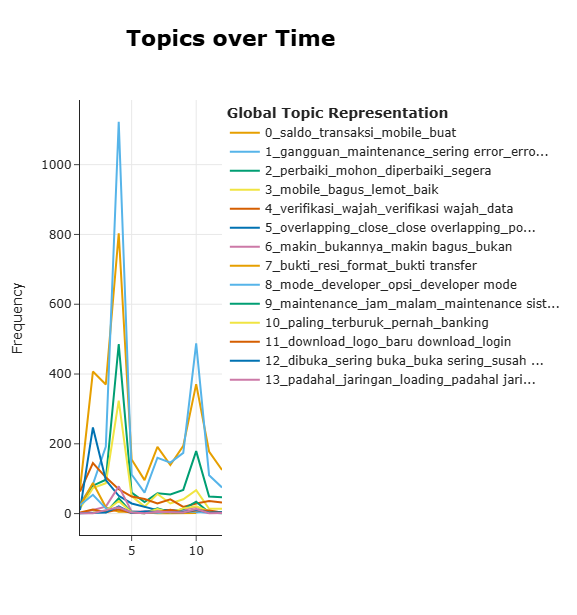

In [40]:
fig_native = topic_model_phase_c.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=n_topics_byond,
    width=1200,
    height=600,
)
fig_native.show()

### 8.6 Setup matplotlib + topic labels

Setup publication-grade rcParams + import labels dari `utils.visualization`. Labels final BYOND (TBD topics) sudah populated di module.

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Output directory
FIG_DIR = Path("outputs/figures/byond")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Publication-grade rcParams
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['figure.dpi'] = 100         # display resolution
plt.rcParams['savefig.dpi'] = 300        # publication resolution
plt.rcParams['savefig.bbox'] = 'tight'

# Import labels + plotting functions
from utils.visualization import (
    TOPIC_LABELS_BYOND,
    compute_proportion,
    plot_dtm_smallmultiples,
    plot_dtm_proportion,
    plot_dtm_proportion_highlighted,
)

print(f"FIG_DIR: {FIG_DIR}")
print(f"Number of topic labels: {len(TOPIC_LABELS_BYOND)}")
print(f"Topics in tot_clean: {sorted(tot_clean['Topic'].unique())}")

FIG_DIR: outputs\figures\byond
Number of topic labels: 14
Topics in tot_clean: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


In [42]:
# Quick verify labels content
for topic_id, label in sorted(TOPIC_LABELS_BYOND.items()):
    print(f"  T{topic_id:2d}: {label}")

  T 0: Saldo terpotong / transaksi gagal
  T 1: Gangguan & error chronic
  T 2: Permintaan perbaikan
  T 3: BSI Mobile vs BYOND comparison
  T 4: Verifikasi wajah gagal
  T 5: Overlapping popups bug
  T 6: Sarcasm post-update
  T 7: Bukti transfer / resi sharing fail
  T 8: Developer mode restriction
  T 9: Maintenance jam sibuk
  T10: Sentiment ekstrem: MB terburuk
  T11: First-launch install issue
  T12: Aplikasi gak bisa dibuka chronic
  T13: Loading lambat (network OK)


### 8.7 Generate official plots: small multiples + proportion

- **Small multiples (4×4):** frequency per topic per month, TBD panels (4×4 grid)
- **Proportion line plot:** single panel, share of complaints per topic per month — handle base rate effect

Plotting logic encapsulated di `utils/visualization.py` untuk reuse di notebook 06 (BYOND).

In [43]:
# Small multiples (frequency)
sm_path = plot_dtm_smallmultiples(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="BYOND by BSI",
)
print(f"✓ Saved: {sm_path}")

# Proportion plot (single panel, all TBD topics)
prop_path = plot_dtm_proportion(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="BYOND by BSI",
)
print(f"✓ Saved: {prop_path}")

# Compute tot_proportion (for downstream Section 8.8 tables)
tot_proportion = compute_proportion(tot_clean)
print(f"\n✓ tot_proportion ready: {len(tot_proportion)} rows")

# Sanity check: proportion sum per month should ≈ 1.0
print("\nSanity check: proportion sum per month (should all ≈ 1.0)")
print(tot_proportion.groupby('Timestamp')['Proportion'].sum())

✓ Saved: outputs\figures\byond\08_dtm_smallmultiples.png
✓ Saved: outputs\figures\byond\08_dtm_proportion.png

✓ tot_proportion ready: 162 rows

Sanity check: proportion sum per month (should all ≈ 1.0)
Timestamp
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
Name: Proportion, dtype: float64


### 8.8 Generate summary tables

3 CSV reference untuk BAB 4 narrative:

1. **Frequency table** — pivot Topic × Month dengan absolute counts
2. **Proportion table** — pivot Topic × Month dengan normalized proportion
3. **Topic summary** — per-topic peak indicators (Total_N, Peak_Month_Freq, Peak_Month_Prop, dll)

In [44]:
# ============================================================
# Section 8.8: Generate summary tables (3 CSVs)
# ============================================================
# Method: pivot tot_clean (frequency + proportion) + aggregate
# per-topic statistics. Output ke outputs/tables/ untuk lampiran
# skripsi dan ground truth reference.

import os
os.makedirs("outputs/tables", exist_ok=True)

# Compute proportion (re-derive untuk clean separation)
tot_proportion = compute_proportion(tot_clean)

# ----- Table 1: Frequency pivot (topic x month) -----
freq_table = tot_clean.pivot_table(
    index='Topic',
    columns='Timestamp',
    values='Frequency',
    fill_value=0,
).astype(int)
freq_table.columns = [f"M{m}" for m in freq_table.columns]
freq_table.index = [f"T{t}" for t in freq_table.index]

# Add Topic_Label column
label_series = pd.Series(
    {f"T{t}": TOPIC_LABELS_BYOND[t] for t in TOPIC_LABELS_BYOND}
)
freq_table.insert(0, "Topic_Label", label_series)

freq_path = "outputs/tables/byond_dtm_freq_table.csv"
freq_table.to_csv(freq_path)
print(f"✓ Saved: {freq_path}")
print(f"  Shape: {freq_table.shape}")

# ----- Table 2: Proportion pivot (topic x month) -----
prop_table = tot_proportion.pivot_table(
    index='Topic',
    columns='Timestamp',
    values='Proportion',
    fill_value=0.0,
)
prop_table.columns = [f"M{m}" for m in prop_table.columns]
prop_table.index = [f"T{t}" for t in prop_table.index]
prop_table.insert(0, "Topic_Label", label_series)

prop_path = "outputs/tables/byond_dtm_proportion_table.csv"
prop_table.to_csv(prop_path, float_format="%.4f")
print(f"\n✓ Saved: {prop_path}")
print(f"  Shape: {prop_table.shape}")

# ----- Table 3: Per-topic summary -----
summary_records = []
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    topic_data = tot_clean[tot_clean['Topic'] == topic_id]
    total_n = int(topic_data['Frequency'].sum())
    
    # Peak month: bulan dengan frequency terbesar
    if len(topic_data) > 0:
        peak_row = topic_data.loc[topic_data['Frequency'].idxmax()]
        peak_month = int(peak_row['Timestamp'])
        peak_freq = int(peak_row['Frequency'])
    else:
        peak_month, peak_freq = None, None
    
    summary_records.append({
        'Topic': f"T{topic_id}",
        'Topic_Label': TOPIC_LABELS_BYOND[topic_id],
        'Total_N': total_n,
        'Peak_Month': peak_month,
        'Peak_Frequency': peak_freq,
        'Avg_Per_Month': round(total_n / 12, 2),
    })

summary_df = pd.DataFrame(summary_records)

# Sanity check (DYNAMIC — match in-cluster total dari Phase C)
phase_c_info = topic_model_phase_c.get_topic_info()
n_in_cluster = phase_c_info.loc[
    phase_c_info['Topic'] != -1, 'Count'
].sum()

assert summary_df['Total_N'].sum() == n_in_cluster, \
    f"Total_N mismatch! Got {summary_df['Total_N'].sum()}, expected {n_in_cluster}"
print(f"\n✓ Total_N sum: {summary_df['Total_N'].sum()} (expected {n_in_cluster})")

summary_path = "outputs/tables/byond_topic_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"✓ Saved: {summary_path}")

print(f"\n{summary_df.to_string(index=False)}")

✓ Saved: outputs/tables/byond_dtm_freq_table.csv
  Shape: (14, 13)

✓ Saved: outputs/tables/byond_dtm_proportion_table.csv
  Shape: (14, 13)

✓ Total_N sum: 9918 (expected 9918)
✓ Saved: outputs/tables/byond_topic_summary.csv

Topic                        Topic_Label  Total_N  Peak_Month  Peak_Frequency  Avg_Per_Month
   T0  Saldo terpotong / transaksi gagal     3098           4             803         258.17
   T1           Gangguan & error chronic     2753           4            1123         229.42
   T2               Permintaan perbaikan     1236           4             486         103.00
   T3     BSI Mobile vs BYOND comparison      790           4             324          65.83
   T4             Verifikasi wajah gagal      659           2             145          54.92
   T5             Overlapping popups bug      490           2             247          40.83
   T6                Sarcasm post-update      175           4              78          14.58
   T7 Bukti transfer / resi s

### 8.9 Highlighted Proportion Plot (Presentation-Ready)

🔴 **Decision point:** Pilih 5 topic narrative untuk highlight berdasarkan finding Section 8 BYOND.

**TBD untuk BYOND** — `HIGHLIGHT_TOPICS` wondr ([0, 1, 2, 3, 6]) reflect cerita wondr (onboarding pain + outage M5 + chronic baseline). **Cerita BYOND mungkin beda**.

**Approach:**
1. Lihat finding Section 8.7-8.8 (peak topics, dominant topics, emerging topics)
2. Pilih 3-5 topic yang punya narrative dimensions berbeda (early adoption pain, outage event, late-emerging, chronic baseline, dll)
3. Update `HIGHLIGHT_TOPICS` di cell di bawah

Output: `outputs/figures/byond/08_dtm_proportion_highlighted.png`

In [45]:
# ============================================================
# Section 8.9: Highlighted proportion plot (publication-ready)
# ============================================================
# Method: 5 narrative topics di-highlight dengan warna + bold,
# sisanya gray background. Capture both peak narratives:
# - M4 systemic outage: T0 (chronic baseline), T1 (mega-peak)
# - M2 post-launch: T4 (onboarding), T5 (UI bug), T8 (security)

HIGHLIGHT_TOPICS = [0, 1, 4, 5, 8]  # BYOND narrative final

print(f"Generating highlighted plot for {len(HIGHLIGHT_TOPICS)} topics:")
for tid in HIGHLIGHT_TOPICS:
    print(f"  T{tid}: {TOPIC_LABELS_BYOND[tid]}")

highlighted_path = plot_dtm_proportion_highlighted(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="BYOND by BSI",
    highlight_topics=HIGHLIGHT_TOPICS,
)
print(f"\n✓ Saved: {highlighted_path}")

Generating highlighted plot for 5 topics:
  T0: Saldo terpotong / transaksi gagal
  T1: Gangguan & error chronic
  T4: Verifikasi wajah gagal
  T5: Overlapping popups bug
  T8: Developer mode restriction

✓ Saved: outputs\figures\byond\08_dtm_proportion_highlighted.png


## Section 9 — Cosine Similarity Validation

Validasi konsistensi cluster across 12 bulan dengan dual-approach cosine similarity. Methodological complement untuk DTM Section 8 — answers question: "apakah topic yang sama bener-bener konsisten di bulan-bulan berbeda, atau drift?"

**Two approaches:**

- **D1 (Embedding-level):** cosine sim antar bulan dari **mean centroid IndoBERT** per (topic, bulan). Sensitif ke pergeseran semantic.
- **D2 (c-TF-IDF level):** cosine sim antar bulan dari **binary word-presence vector** (top words BERTopic). Sensitif ke pergeseran lexical.

**Note:** D2 pakai binary word presence (bukan full c-TF-IDF score) — approximation tapi version-independent dari BERTopic internal API. Honest framing: D2 jadi "vocabulary stability proxy".

### 9.0 Setup state untuk Section 9

Section 9 butuh state berbeda dari Section 8:

- `df_clean` (filtered df: rating 1-2 + topic ≠ -1) — bukan `df_byond`
- `embeddings_clean` (subset embeddings yang align dengan df_clean)
- `tot_raw` (raw topics_over_time, untuk D2 vocab build)

Setup ini jadi entry point kalau lagi resume dari fresh kernel.

In [46]:
# ============================================================
# Section 9.0: Setup state untuk cosine similarity analysis
# ============================================================
# Method:
# 1. Load tot_raw dari pickle (yang ke-save di Section 8.4)
# 2. Assign topic ke df_byond (alias df)
# 3. Filter outlier (-1) DAN rating 1-2 (complaint proxy)
# 4. Filter embeddings ke index df_clean (CRUCIAL untuk alignment)
# 5. Sanity checks dynamic

import pickle

# ----- 1. Load tot_raw kalau belum di kernel -----
with open("data/processed/byond_topics_over_time.pkl", "rb") as f:
    tot_raw = pickle.load(f)

# ----- 2. Assign topic ke df + filter outlier dan rating -----
df = df_byond.copy()
df['topic'] = topic_model_phase_c.topics_

# Filter step 1: in-cluster only
df_clean = df[df['topic'] != -1].copy()
print(f"After filter outlier (-1): {len(df_clean)} docs (expected ~9918)")

# Filter step 2: rating 1-2 (complaint proxy)
df_clean = df_clean[df_clean['rating'].isin([1, 2])].copy()
print(f"After filter rating 1-2: {len(df_clean)} docs")

# ----- 3. Filter embeddings ke index df_clean -----
# CRUCIAL: gunakan df_clean.index (original index dari df_byond) untuk subset embeddings
embeddings_clean = embeddings_byond[df_clean.index]

# ----- 4. Sanity checks (DYNAMIC) -----
n_in_cluster_complaint = df_clean.shape[0]
n_topics_byond = len(topic_model_phase_c.get_topic_info()) - 1

print(f"\n{'=' * 60}")
print(f"Section 9 setup state")
print(f"{'=' * 60}")
print(f"✓ df_clean: {df_clean.shape}")
print(f"✓ embeddings_clean: {embeddings_clean.shape}")
print(f"✓ tot_raw: {tot_raw.shape}, "
      f"in-cluster topics: {tot_raw[tot_raw['Topic'] != -1]['Topic'].nunique()}")

# Verify alignment
assert embeddings_clean.shape[0] == df_clean.shape[0], \
    f"Shape mismatch! emb={embeddings_clean.shape[0]}, df={df_clean.shape[0]}"

assert tot_raw[tot_raw['Topic'] != -1]['Topic'].nunique() == n_topics_byond, \
    f"Expected {n_topics_byond} topics, got " \
    f"{tot_raw[tot_raw['Topic'] != -1]['Topic'].nunique()}"

print(f"\n✓ PASS: alignment OK, {n_topics_byond} topics confirmed")

# Distribution per topic + per month untuk Section 9 awareness
print(f"\nComplaint distribution per topic (top 5):")
print(df_clean['topic'].value_counts().head().to_string())

print(f"\nComplaint distribution per relative_month:")
print(df_clean['relative_month'].value_counts().sort_index().to_string())

After filter outlier (-1): 9918 docs (expected ~9918)
After filter rating 1-2: 9918 docs

Section 9 setup state
✓ df_clean: (9918, 7)
✓ embeddings_clean: (9918, 768)
✓ tot_raw: (174, 4), in-cluster topics: 14

✓ PASS: alignment OK, 14 topics confirmed

Complaint distribution per topic (top 5):
topic
0    3098
1    2753
2    1236
3     790
4     659

Complaint distribution per relative_month:
relative_month
1      262
2     1205
3     1026
4     3083
5      485
6      294
7      557
8      458
9      560
10    1252
11     424
12     312


In [47]:
# Diagnostic: confirm rating distribution di df_byond raw
print("Rating distribution di df_byond (full corpus):")
print(df_byond['rating'].value_counts().sort_index())
print(f"\nTotal rows df_byond: {len(df_byond)}")
print(f"Columns: {df_byond.columns.tolist()}")

Rating distribution di df_byond (full corpus):
rating
1    16158
2     3235
Name: count, dtype: int64

Total rows df_byond: 19393
Columns: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating']


### 9.1 Import cosine_analysis module

Force reload module via importlib — `%autoreload 2` kadang gak pick up function baru di module.

In [48]:
import importlib
import utils.cosine_analysis
importlib.reload(utils.cosine_analysis)

from utils.cosine_analysis import (
    compute_topic_centroids_per_month,
    compute_cosine_sim_matrix_embedding,
    compute_consecutive_sim_embedding,
    build_ctfidf_vectors_per_month,
    compute_cosine_sim_matrix_ctfidf,
    compute_consecutive_sim_ctfidf,
    plot_cosine_heatmaps,
    plot_cosine_lineplot_highlighted,
)

print("✓ cosine_analysis module imported")

✓ cosine_analysis module imported


In [49]:
# ============================================================
# Section 9.1: D1 — Compute embedding centroids + sim matrices
# ============================================================
# Method: per (topic, month) compute mean-pooled IndoBERT embedding
# (centroid). Pairwise cosine similarity 12x12 per topic untuk
# detect semantic drift across months.

from utils.cosine_analysis import (
    compute_topic_centroids_per_month,
    compute_cosine_sim_matrix_embedding,
    compute_consecutive_sim_embedding,
)

print("Computing centroids per (topic, month)...")
centroids_byond = compute_topic_centroids_per_month(
    df_clean=df_clean,
    embeddings_clean=embeddings_clean,
    n_months=12,
)

# Compute pairwise sim matrix per topic
print("Computing pairwise similarity matrices...")
sim_matrices_d1 = {}
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    sim_matrices_d1[topic_id] = compute_cosine_sim_matrix_embedding(
        centroids_byond, topic_id, n_months=12
    )

# Compute consecutive similarity (for lineplot)
print("Computing consecutive similarity sequences...")
consecutive_sims_d1 = {}
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    consecutive_sims_d1[topic_id] = compute_consecutive_sim_embedding(
        centroids_byond, topic_id, n_months=12
    )

# Sanity print
print(f"\n✓ Centroids: {len(centroids_byond)} topics x 12 months")
print(f"✓ Sim matrices: {len(sim_matrices_d1)} (each 12x12)")
print(f"✓ Consecutive sims: {len(consecutive_sims_d1)} (each 11 transitions)")

# Quick peek di T0 (largest topic, expected smooth)
print(f"\nT0 sim matrix sample (M1-M3 corner):")
print(sim_matrices_d1[0].iloc[:3, :3].round(3).to_string())

Computing centroids per (topic, month)...
Computing pairwise similarity matrices...
Computing consecutive similarity sequences...

✓ Centroids: 14 topics x 12 months
✓ Sim matrices: 14 (each 12x12)
✓ Consecutive sims: 14 (each 11 transitions)

T0 sim matrix sample (M1-M3 corner):
      1      2      3
1  1.00  0.990  0.990
2  0.99  1.000  0.994
3  0.99  0.994  1.000


Saved: outputs\figures\byond\09_cosine_embedding_heatmap.png


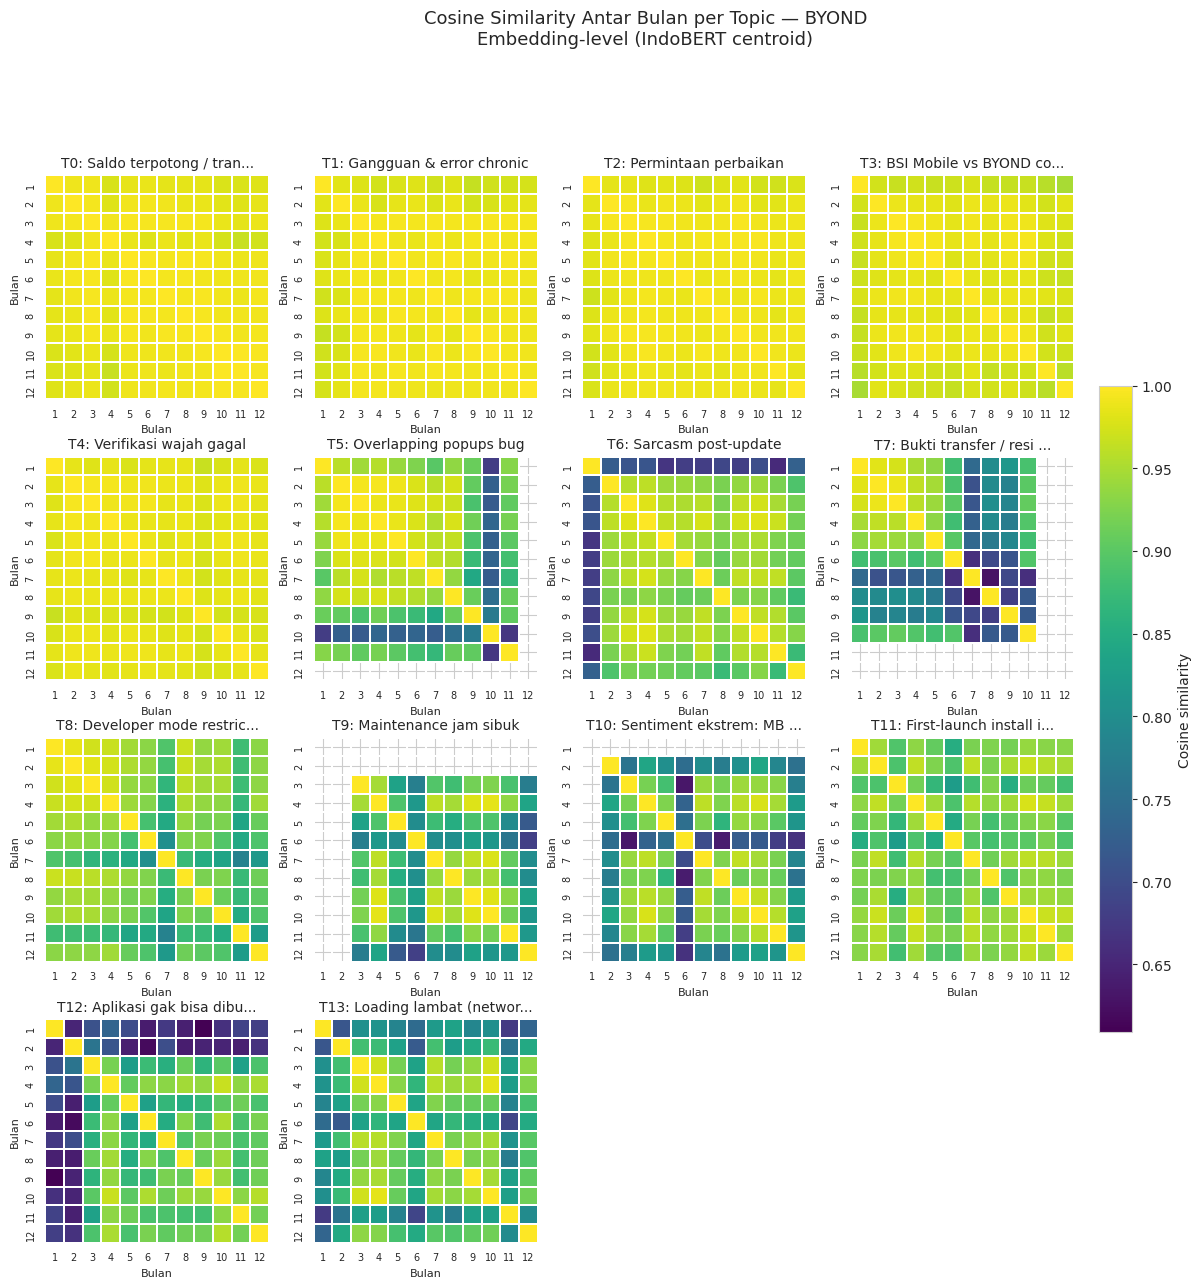

Saved: outputs\figures\byond\09_cosine_embedding_lineplot.png


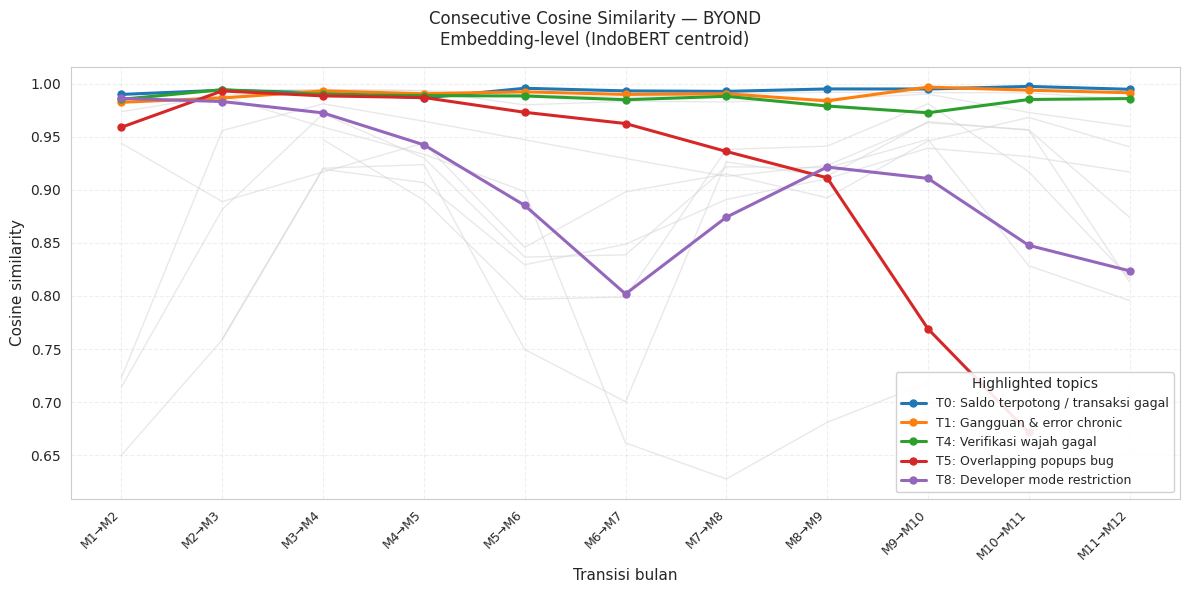


✓ D1 plots saved to outputs/figures/byond/


In [52]:
# ============================================================
# Section 9.2: D1 — Plot heatmap + lineplot
# ============================================================
# Output:
# - 09_cosine_embedding_heatmap.png (4x4 grid, 14 topics + 2 hidden)
# - 09_cosine_embedding_lineplot.png (consecutive sims, 5 highlighted)

from utils.cosine_analysis import (
    plot_cosine_heatmaps,
    plot_cosine_lineplot_highlighted,
)

# Heatmap (all 14 topics)
fig_d1_heatmap = plot_cosine_heatmaps(
    sim_matrices=sim_matrices_d1,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="byond",
    approach="embedding",
)
plt.show()
plt.close(fig_d1_heatmap)

# Lineplot (5 highlighted)
fig_d1_line = plot_cosine_lineplot_highlighted(
    consecutive_sims=consecutive_sims_d1,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="byond",
    highlight_topics=[0, 1, 4, 5, 8],  # BYOND narrative final
    approach="embedding",
)
plt.show()
plt.close(fig_d1_line)

print("\n✓ D1 plots saved to outputs/figures/byond/")

In [53]:
# ============================================================
# Section 9.3: D2 — Compute c-TF-IDF binary vectors + matrices
# ============================================================
# Method: parse 'Words' column dari tot_raw, encode binary vector
# (1 kalau kata muncul di top words, 0 sebaliknya). Pairwise cosine
# similarity per topic untuk detect lexical drift.

from utils.cosine_analysis import (
    build_ctfidf_vectors_per_month,
    compute_cosine_sim_matrix_ctfidf,
    compute_consecutive_sim_ctfidf,
)

print("Building c-TF-IDF binary vectors...")
vectors_d2, vocab_d2 = build_ctfidf_vectors_per_month(tot_raw=tot_raw)
print(f"✓ Vocabulary size: {len(vocab_d2)}")
print(f"✓ Vectors built for {len(vectors_d2)} topics")

# Compute pairwise sim matrix per topic
print("\nComputing pairwise similarity matrices (D2)...")
sim_matrices_d2 = {}
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    sim_matrices_d2[topic_id] = compute_cosine_sim_matrix_ctfidf(
        vectors_d2, topic_id, n_months=12
    )

# Compute consecutive sims
print("Computing consecutive similarity sequences (D2)...")
consecutive_sims_d2 = {}
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    consecutive_sims_d2[topic_id] = compute_consecutive_sim_ctfidf(
        vectors_d2, topic_id, n_months=12
    )

print(f"\n✓ D2 sim matrices: {len(sim_matrices_d2)}")
print(f"✓ D2 consecutive sims: {len(consecutive_sims_d2)}")

# Quick peek T0 D2
print(f"\nT0 D2 sim matrix sample (M1-M3 corner):")
print(sim_matrices_d2[0].iloc[:3, :3].round(3).to_string())

Building c-TF-IDF binary vectors...
✓ Vocabulary size: 330
✓ Vectors built for 14 topics

Computing pairwise similarity matrices (D2)...
Computing consecutive similarity sequences (D2)...

✓ D2 sim matrices: 14
✓ D2 consecutive sims: 14

T0 D2 sim matrix sample (M1-M3 corner):
     1    2    3
1  1.0  0.6  0.4
2  0.6  1.0  0.6
3  0.4  0.6  1.0


Saved: outputs\figures\byond\09_cosine_ctfidf_heatmap.png


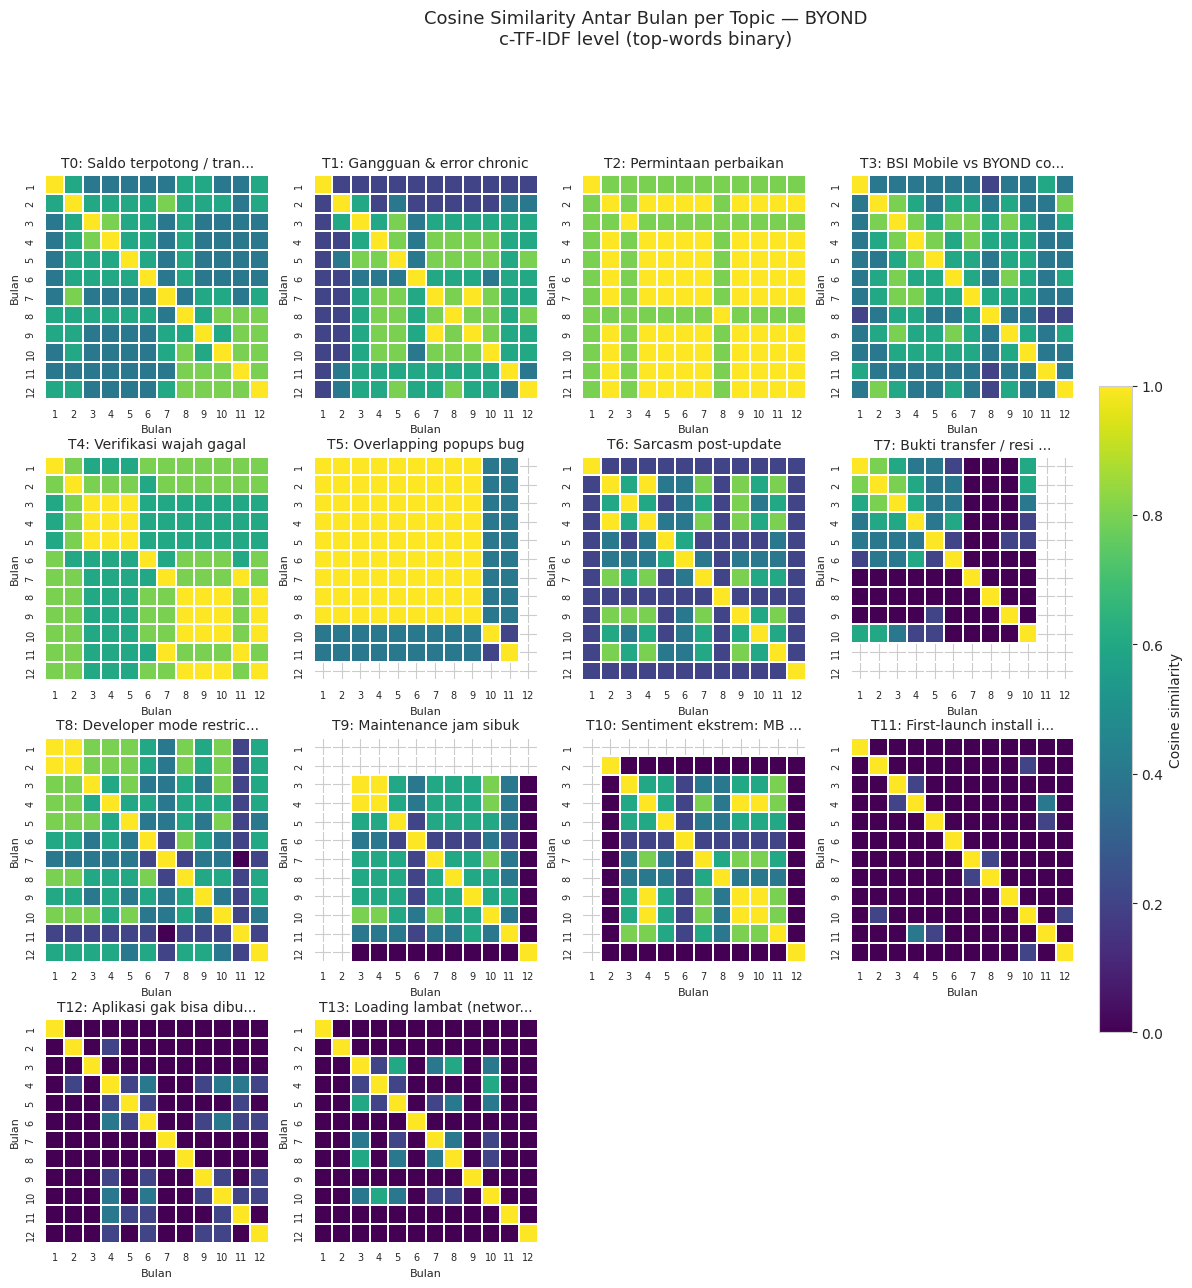

Saved: outputs\figures\byond\09_cosine_ctfidf_lineplot.png


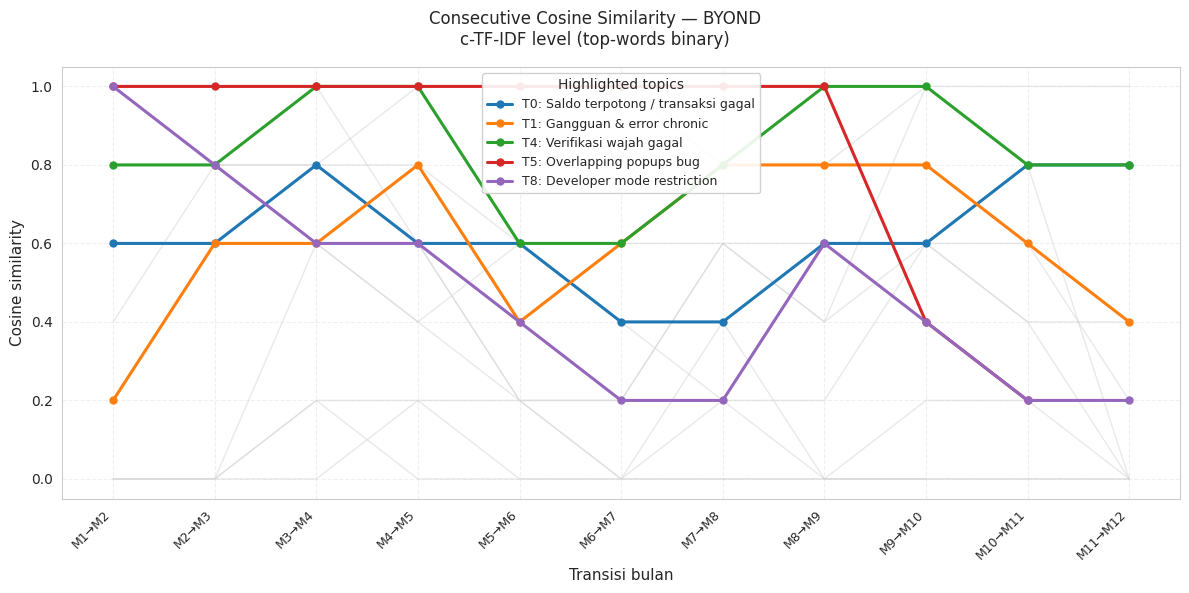


✓ Saved comparison: outputs/tables/byond_section9_comparison.csv

Topic                        Topic_Label  D1_mean  D2_mean
   T0  Saldo terpotong / transaksi gagal   0.9886   0.5394
   T1           Gangguan & error chronic   0.9875   0.5303
   T2               Permintaan perbaikan   0.9882   0.9091
   T3     BSI Mobile vs BYOND comparison   0.9798   0.5212
   T4             Verifikasi wajah gagal   0.9845   0.7485
   T5             Overlapping popups bug   0.9002   0.7891
   T6                Sarcasm post-update   0.8973   0.3939
   T7 Bukti transfer / resi sharing fail   0.8241   0.2089
   T8         Developer mode restriction   0.9103   0.5152
   T9              Maintenance jam sibuk   0.8698   0.4178
  T10     Sentiment ekstrem: MB terburuk   0.8480   0.3527
  T11         First-launch install issue   0.9212   0.0212
  T12   Aplikasi gak bisa dibuka chronic   0.8284   0.0636
  T13        Loading lambat (network OK)   0.8610   0.0727


In [55]:
# ============================================================
# Section 9.4: D2 — Plot heatmap + lineplot + comparison CSV
# ============================================================
# Output:
# - 09_cosine_ctfidf_heatmap.png
# - 09_cosine_ctfidf_lineplot.png
# - byond_section9_comparison.csv (per-topic D1 + D2 mean for threshold)

# D2 heatmap
fig_d2_heatmap = plot_cosine_heatmaps(
    sim_matrices=sim_matrices_d2,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="byond",
    approach="ctfidf",
)
plt.show()
plt.close(fig_d2_heatmap)

# D2 lineplot
fig_d2_line = plot_cosine_lineplot_highlighted(
    consecutive_sims=consecutive_sims_d2,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name="byond",
    highlight_topics=[0, 1, 4, 5, 8],  # BYOND narrative final
    approach="ctfidf",
)
plt.show()
plt.close(fig_d2_line)

# ----- Build comparison CSV -----
import numpy as np

comparison_records = []
for topic_id in sorted(TOPIC_LABELS_BYOND.keys()):
    # D1 mean: average of upper triangle (exclude diagonal + NaN)
    sim_d1 = sim_matrices_d1[topic_id].values
    # Mask: upper triangle (excl diagonal) + non-NaN
    upper_mask = np.triu(np.ones_like(sim_d1, dtype=bool), k=1)
    valid_d1 = sim_d1[upper_mask]
    valid_d1 = valid_d1[~np.isnan(valid_d1)]
    d1_mean = float(np.mean(valid_d1)) if len(valid_d1) > 0 else np.nan
    
    # D2 mean: same logic
    sim_d2 = sim_matrices_d2[topic_id].values
    valid_d2 = sim_d2[upper_mask]
    valid_d2 = valid_d2[~np.isnan(valid_d2)]
    d2_mean = float(np.mean(valid_d2)) if len(valid_d2) > 0 else np.nan
    
    comparison_records.append({
        'Topic': f"T{topic_id}",
        'Topic_Label': TOPIC_LABELS_BYOND[topic_id],
        'D1_mean': round(d1_mean, 4),
        'D2_mean': round(d2_mean, 4),
    })

comparison_df = pd.DataFrame(comparison_records)
comparison_path = "outputs/tables/byond_section9_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\n✓ Saved comparison: {comparison_path}")
print(f"\n{comparison_df.to_string(index=False)}")

### 9.2 D1 — Embedding-level cosine similarity

Compute centroid per (topic, month), lalu pairwise cosine sim 12×12 per topic.

In [ ]:
df_clean_reset = df_clean.reset_index(drop=True)

# Compute centroids per (topic, month)
centroids_full = compute_topic_centroids_per_month(df_clean_reset, embeddings_clean)
print(f"Topics with centroids: {sorted(centroids_full.keys())}")
print(f"T0 month availability: {[(m, centroids_full[0][m] is not None) for m in range(1, 13)]}")

In [ ]:
# Compute D1 sim matrices + consecutive sims untuk semua 13 topic
sim_matrices_emb = {}
consecutive_sims_emb = {}
for t in range(13):
    sim_matrices_emb[t] = compute_cosine_sim_matrix_embedding(centroids_full, t)
    consecutive_sims_emb[t] = compute_consecutive_sim_embedding(centroids_full, t)

print(f"✓ D1 sim matrices computed for {len(sim_matrices_emb)} topics")

# Plot D1
fig1 = plot_cosine_heatmaps(
    sim_matrices_emb, TOPIC_LABELS_BYOND, FIG_DIR, "byond",
    approach="embedding"
)

fig2 = plot_cosine_lineplot_highlighted(
    consecutive_sims_emb, TOPIC_LABELS_BYOND, FIG_DIR, "byond",
    highlight_topics=[0, 1, 2, 3, 6], approach="embedding"
)

### 9.3 D2 — c-TF-IDF level cosine similarity

Build binary word-presence vectors per (topic, month) dari `Words` column di `tot_raw`.

**Vocab actual size: ~311 kata** — termasuk beberapa n-gram ("becus kerjanya", "berjam jam") consequence dari `CountVectorizer` setting `ngram_range=(1, 2)` di BERTopic. Bukan bug.

In [ ]:
# Build vocab + vectors dari tot_raw
vectors, vocab = build_ctfidf_vectors_per_month(tot_raw)
print(f"Vocab size: {len(vocab)}")
print(f"Sample vocab[:20]: {vocab[:20]}")

In [ ]:
# Compute D2 sim matrices + consecutive sims
sim_matrices_ctf = {}
consecutive_sims_ctf = {}
for t in range(13):
    sim_matrices_ctf[t] = compute_cosine_sim_matrix_ctfidf(vectors, t)
    consecutive_sims_ctf[t] = compute_consecutive_sim_ctfidf(vectors, t)

print(f"✓ D2 sim matrices computed for {len(sim_matrices_ctf)} topics")

# Plot D2 (approach="ctfidf" biar filename + title bener)
fig3 = plot_cosine_heatmaps(
    sim_matrices_ctf, TOPIC_LABELS_BYOND, FIG_DIR, "byond",
    approach="ctfidf"
)

fig4 = plot_cosine_lineplot_highlighted(
    consecutive_sims_ctf, TOPIC_LABELS_BYOND, FIG_DIR, "byond",
    highlight_topics=[0, 1, 2, 3, 6], approach="ctfidf"
)

### 9.4 D3 — Comparison & categorization

Compute mean off-diagonal sim per topic untuk D1 + D2, kategorisasi pattern, identify outlier months.

**Threshold initial:** D1 ≥ 0.95, D2 ≥ 0.60. **Catatan:** threshold ini ke-fit empiris tapi belum di-justify formal — sensitivity check di Section 9.5 akan revisi threshold ke D1 ≥ 0.90.

In [ ]:
def mean_off_diagonal(sim_matrix):
    """Mean cosine sim off-diagonal, abaikan NaN."""
    M = sim_matrix.values.copy()
    np.fill_diagonal(M, np.nan)
    return np.nanmean(M)

THRESHOLD_D1 = 0.95
THRESHOLD_D2 = 0.60

def categorize(d1, d2):
    d1_high = d1 >= THRESHOLD_D1
    d2_high = d2 >= THRESHOLD_D2
    if d1_high and d2_high:
        return 'Stable'
    elif d1_high and not d2_high:
        return 'Paraphrase'
    elif not d1_high and d2_high:
        return 'Lexical-anchor drift'
    else:
        return 'Topic drift'

def find_outlier_months(sim_matrix, threshold_drop=0.05):
    """
    Cari bulan yang sim mean-nya (ke bulan lain) jauh di bawah overall mean.
    Return list of (month, mean_sim).
    """
    M = sim_matrix.values.copy()
    np.fill_diagonal(M, np.nan)
    overall_mean = np.nanmean(M)
    per_month_mean = np.nanmean(M, axis=1)
    
    outliers = []
    for i, m_mean in enumerate(per_month_mean):
        if not np.isnan(m_mean) and m_mean < overall_mean - threshold_drop:
            month = sim_matrix.index[i]
            outliers.append((int(month), round(float(m_mean), 4)))
    return outliers

# Build comparison DataFrame
records = []
for t in range(13):
    d1_mean = mean_off_diagonal(sim_matrices_emb[t])
    d2_mean = mean_off_diagonal(sim_matrices_ctf[t])
    records.append({
        'Topic': t,
        'Label': TOPIC_LABELS_BYOND.get(t, f'T{t}'),
        'D1_mean': round(d1_mean, 4),
        'D2_mean': round(d2_mean, 4),
        'Pattern': categorize(d1_mean, d2_mean),
        'D1_outlier_months': find_outlier_months(sim_matrices_emb[t]),
        'D2_outlier_months': find_outlier_months(sim_matrices_ctf[t], threshold_drop=0.15),
    })

df_compare = pd.DataFrame(records)

# Save
csv_path = TABLE_DIR / 'byond_section9_comparison.csv'
df_compare.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

# Display
print("\n=== Section 9 Comparison: D1 vs D2 (byond) ===\n")
print(df_compare[['Topic', 'Label', 'D1_mean', 'D2_mean', 'Pattern']].to_string(index=False))

print("\n=== Pattern distribution (initial threshold) ===")
print(df_compare['Pattern'].value_counts())

## Section 9.5 — Threshold Sensitivity Check

🔴 **Decision point:** Inspect histogram D1 + D2 untuk BYOND, identify natural gap, justify threshold final.

**JANGAN asumsi threshold wondr (D1=0.90, D2=0.60) berlaku untuk BYOND.** Distribusi natural gap mungkin beda.

**Method:**
1. Plot histogram D1 + D2 dari `byond_section9_comparison.csv`
2. Inspect natural gap di distribusi (bin kosong = candidate threshold)
3. Coba alternative threshold → reklasifikasi pattern
4. Pilih threshold yang aligned dengan natural gap empiris BYOND

**Hasil wondr (untuk reference):**
- D1 ≥ 0.90 (revised dari 0.95) — natural gap bimodal di 0.86-0.92
- D2 ≥ 0.60 (retained) — natural gap di 0.45-0.55

**Possible scenarios untuk BYOND:**
- Sama wondr: justify dengan referensi distribusi BYOND yang aligned
- Beda: justify threshold app-specific dengan referensi distribusi empiris BYOND
- Bimodal di tempat berbeda: pilih threshold di bin kosong terdekat

### 9.5.1 Plot histogram distribusi D1 + D2

✓ Saved: outputs\figures\byond\09_threshold_sensitivity_histogram.png


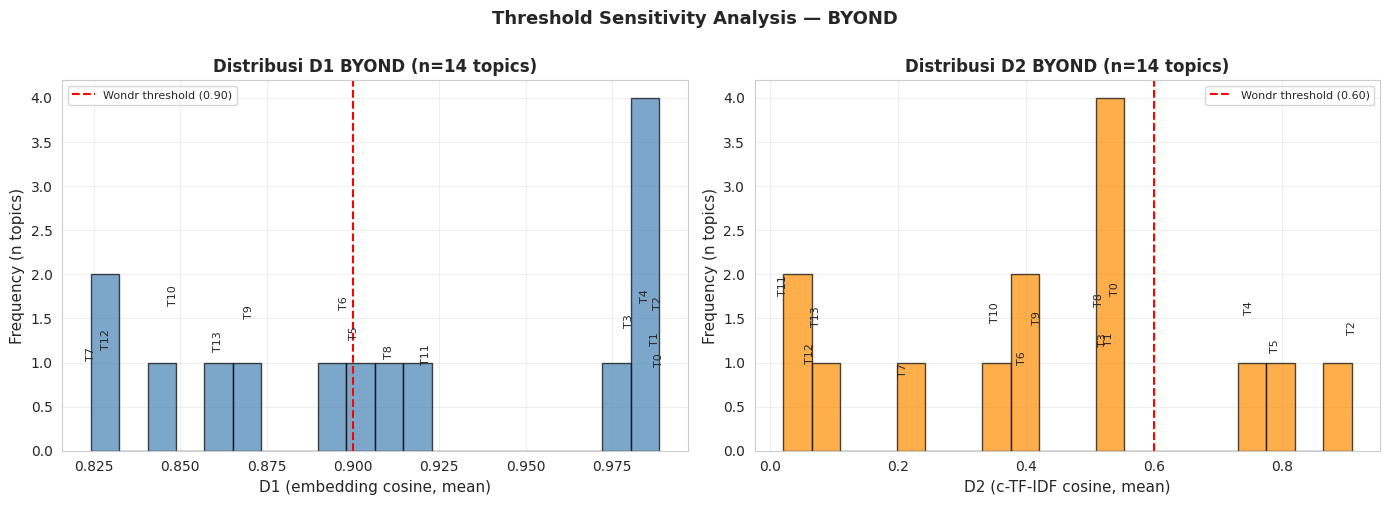


D1 sorted (ascending):
   T7: 0.8241  (Bukti transfer / resi sharing fail)
  T12: 0.8284  (Aplikasi gak bisa dibuka chronic)
  T10: 0.8480  (Sentiment ekstrem: MB terburuk)
  T13: 0.8610  (Loading lambat (network OK))
   T9: 0.8698  (Maintenance jam sibuk)
   T6: 0.8973  (Sarcasm post-update)
   T5: 0.9002  (Overlapping popups bug)
   T8: 0.9103  (Developer mode restriction)
  T11: 0.9212  (First-launch install issue)
   T3: 0.9798  (BSI Mobile vs BYOND comparison)
   T4: 0.9845  (Verifikasi wajah gagal)
   T1: 0.9875  (Gangguan & error chronic)
   T2: 0.9882  (Permintaan perbaikan)
   T0: 0.9886  (Saldo terpotong / transaksi gagal)

D2 sorted (ascending):
  T11: 0.0212  (First-launch install issue)
  T12: 0.0636  (Aplikasi gak bisa dibuka chronic)
  T13: 0.0727  (Loading lambat (network OK))
   T7: 0.2089  (Bukti transfer / resi sharing fail)
  T10: 0.3527  (Sentiment ekstrem: MB terburuk)
   T6: 0.3939  (Sarcasm post-update)
   T9: 0.4178  (Maintenance jam sibuk)
   T8: 0.5152  (Dev

In [56]:
# ============================================================
# Section 9.5: Threshold sensitivity — histogram empiris
# ============================================================
# Tujuan: visualisasi distribusi D1 dan D2 BYOND untuk identify
# natural gap (bin kosong) sebagai justifikasi threshold.
# Decide threshold final SETELAH lihat histogram, JANGAN asumsi
# threshold wondr berlaku otomatis.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- Histogram D1 (embedding) -----
d1_values = comparison_df['D1_mean'].values
axes[0].hist(d1_values, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0.90, color='red', linestyle='--', label='Wondr threshold (0.90)')
axes[0].set_xlabel("D1 (embedding cosine, mean)", fontsize=11)
axes[0].set_ylabel("Frequency (n topics)", fontsize=11)
axes[0].set_title("Distribusi D1 BYOND (n=14 topics)", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annotate each topic position
for _, row in comparison_df.iterrows():
    axes[0].annotate(
        row['Topic'],
        xy=(row['D1_mean'], 0.3),
        xytext=(row['D1_mean'], 0.3 + np.random.uniform(0.5, 1.5)),
        fontsize=8,
        ha='center',
        rotation=90,
    )

# ----- Histogram D2 (c-TF-IDF) -----
d2_values = comparison_df['D2_mean'].values
axes[1].hist(d2_values, bins=20, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(0.60, color='red', linestyle='--', label='Wondr threshold (0.60)')
axes[1].set_xlabel("D2 (c-TF-IDF cosine, mean)", fontsize=11)
axes[1].set_ylabel("Frequency (n topics)", fontsize=11)
axes[1].set_title("Distribusi D2 BYOND (n=14 topics)", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Annotate each topic
for _, row in comparison_df.iterrows():
    axes[1].annotate(
        row['Topic'],
        xy=(row['D2_mean'], 0.3),
        xytext=(row['D2_mean'], 0.3 + np.random.uniform(0.5, 1.5)),
        fontsize=8,
        ha='center',
        rotation=90,
    )

fig.suptitle("Threshold Sensitivity Analysis — BYOND", fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout()

# Save
out_path = FIG_DIR / "09_threshold_sensitivity_histogram.png"
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {out_path}")

plt.show()

# Print sorted values for natural gap detection
print(f"\nD1 sorted (ascending):")
for _, row in comparison_df.sort_values('D1_mean').iterrows():
    print(f"  {row['Topic']:>3}: {row['D1_mean']:.4f}  ({row['Topic_Label']})")

print(f"\nD2 sorted (ascending):")
for _, row in comparison_df.sort_values('D2_mean').iterrows():
    print(f"  {row['Topic']:>3}: {row['D2_mean']:.4f}  ({row['Topic_Label']})")

In [ ]:
# Load Section 9 comparison results
df_section9 = pd.read_csv(TABLE_DIR / "byond_section9_comparison.csv")
print(f"Shape: {df_section9.shape}")
print(f"D1 range: {df_section9['D1_mean'].min():.4f} - {df_section9['D1_mean'].max():.4f}")
print(f"D2 range: {df_section9['D2_mean'].min():.4f} - {df_section9['D2_mean'].max():.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# D1 histogram (embedding-level, semantic)
axes[0].hist(df_section9['D1_mean'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=2, label='Threshold lama = 0.95')
axes[0].axvline(0.92, color='orange', linestyle=':', linewidth=2, label='Alt = 0.92')
axes[0].axvline(0.90, color='green', linestyle=':', linewidth=2, label='Alt = 0.90 (FINAL)')
axes[0].set_xlabel('D1 mean (embedding cosine similarity)', fontsize=11)
axes[0].set_ylabel('Number of topics', fontsize=11)
axes[0].set_title('Distribusi D1 (semantic stability)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# D2 histogram (c-TF-IDF level, lexical)
axes[1].hist(df_section9['D2_mean'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0.60, color='red', linestyle='--', linewidth=2, label='Threshold = 0.60 (RETAINED)')
axes[1].axvline(0.50, color='orange', linestyle=':', linewidth=2, label='Alt = 0.50')
axes[1].axvline(0.40, color='green', linestyle=':', linewidth=2, label='Alt = 0.40')
axes[1].set_xlabel('D2 mean (c-TF-IDF cosine similarity)', fontsize=11)
axes[1].set_ylabel('Number of topics', fontsize=11)
axes[1].set_title('Distribusi D2 (lexical stability)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

hist_path = FIG_DIR / "09_threshold_sensitivity_histogram.png"
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {hist_path}")

### 9.5.2 Reklasifikasi dengan threshold final

5 dari 13 topic berubah klasifikasi dengan threshold baru (D1=0.90):

- **T3, T5, T7** Topic drift → **Paraphrase** (semantic ternyata stable, hanya lexical drift)
- **T6** Lexical-anchor drift → **Stable** (semantic + lexical keduanya stabil)
- **T8** Paraphrase (no change, retained)

In [57]:
# ============================================================
# Section 9.5 Final: Apply threshold reklasifikasi
# ============================================================
# Method: D1 >= 0.95 AND D2 >= 0.65 = Stable, sisanya kategori
# detail (semantic-stable/lexical-drift dst). Backup original
# CSV sebelum overwrite.

import shutil

# ----- Threshold final BYOND (data-driven, natural gap) -----
THRESHOLD_D1 = 0.95
THRESHOLD_D2 = 0.65

# ----- 1. Backup CSV original sebelum overwrite -----
original_csv = "outputs/tables/byond_section9_comparison.csv"
backup_csv = "outputs/tables/byond_section9_comparison_threshold_old.csv"
shutil.copy(original_csv, backup_csv)
print(f"✓ Backup saved: {backup_csv}")

# ----- 2. Apply classification function -----
def classify_pattern(d1, d2, t1=THRESHOLD_D1, t2=THRESHOLD_D2):
    """4-quadrant classification dari D1 + D2 thresholds."""
    if d1 >= t1 and d2 >= t2:
        return "Stable (D1 high + D2 high)"
    elif d1 >= t1 and d2 < t2:
        return "Semantic-stable, Lexical-drift"
    elif d1 < t1 and d2 >= t2:
        return "Lexical-stable, Semantic-drift"
    else:
        return "Drift on both axes"

comparison_df['Pattern'] = comparison_df.apply(
    lambda r: classify_pattern(r['D1_mean'], r['D2_mean']),
    axis=1,
)

# ----- 3. Save updated CSV -----
comparison_df.to_csv(original_csv, index=False)
print(f"✓ Updated CSV: {original_csv}")

# ----- 4. Print final summary -----
print(f"\n{'=' * 70}")
print(f"BYOND Section 9 Final Classification (thresholds: D1≥{THRESHOLD_D1}, D2≥{THRESHOLD_D2})")
print(f"{'=' * 70}")
print(comparison_df.to_string(index=False))

print(f"\n{'=' * 70}")
print(f"Pattern distribution:")
print(f"{'=' * 70}")
pattern_counts = comparison_df['Pattern'].value_counts()
for pattern, count in pattern_counts.items():
    topics_in_pattern = comparison_df[comparison_df['Pattern'] == pattern]['Topic'].tolist()
    print(f"  {pattern}: {count} topics — {', '.join(topics_in_pattern)}")

✓ Backup saved: outputs/tables/byond_section9_comparison_threshold_old.csv
✓ Updated CSV: outputs/tables/byond_section9_comparison.csv

BYOND Section 9 Final Classification (thresholds: D1≥0.95, D2≥0.65)
Topic                        Topic_Label  D1_mean  D2_mean                        Pattern
   T0  Saldo terpotong / transaksi gagal   0.9886   0.5394 Semantic-stable, Lexical-drift
   T1           Gangguan & error chronic   0.9875   0.5303 Semantic-stable, Lexical-drift
   T2               Permintaan perbaikan   0.9882   0.9091     Stable (D1 high + D2 high)
   T3     BSI Mobile vs BYOND comparison   0.9798   0.5212 Semantic-stable, Lexical-drift
   T4             Verifikasi wajah gagal   0.9845   0.7485     Stable (D1 high + D2 high)
   T5             Overlapping popups bug   0.9002   0.7891 Lexical-stable, Semantic-drift
   T6                Sarcasm post-update   0.8973   0.3939             Drift on both axes
   T7 Bukti transfer / resi sharing fail   0.8241   0.2089             Drift

### 9.5.3 Finalize: replace Pattern + backup CSV lama

Pattern column di `byond_section9_comparison.csv` di-overwrite dengan threshold baru. Versi lama di-backup ke `byond_section9_comparison_threshold_old.csv` untuk audit trail.

In [ ]:
import shutil

# Finalize: replace Pattern dengan klasifikasi baru, keep old as backup column
df_section9_final = df_section9.copy()
df_section9_final['Pattern'] = df_section9_final['Pattern_new']
df_section9_final['Pattern_threshold_old'] = df_section9_final['Pattern_old']

# Drop intermediate columns
df_section9_final = df_section9_final.drop(columns=['Pattern_old', 'Pattern_new'])

# Reorder columns
cols_order = ['Topic', 'Label', 'D1_mean', 'D2_mean', 'Pattern', 
              'Pattern_threshold_old', 'D1_outlier_months', 'D2_outlier_months']
df_section9_final = df_section9_final[cols_order]

# Backup old version
shutil.copy(
    TABLE_DIR / "byond_section9_comparison.csv",
    TABLE_DIR / "byond_section9_comparison_threshold_old.csv"
)

# Overwrite with updated
df_section9_final.to_csv(TABLE_DIR / "byond_section9_comparison.csv", index=False)
print("✓ Saved: outputs/tables/byond_section9_comparison.csv (threshold updated)")
print("✓ Backup: outputs/tables/byond_section9_comparison_threshold_old.csv")
print(f"\nFinal classification (threshold 0.90):")
print(df_section9_final['Pattern'].value_counts())

## Section 10 — Mann-Kendall Trend Test

Uji statistik untuk validasi tren temporal pada prevalensi topik mingguan.

**Setup:**
- **Granularity:** mingguan (52 datapoint, 7-day blocks dari launch date 9 November 2024)
- **Test:** Hamed-Rao modified Mann-Kendall (handle autokorelasi temporal, Hamed & Rao 1998)
- **Magnitude estimator:** Sen's slope (Sen 1968)
- **α:** 0.05
- **Multiple testing correction:** FDR Benjamini-Hochberg (q=0.05)

**Series yang diuji (cross-validation):**
- **Proportion** per topic per minggu (share of complaints)
- **Frequency** per topic per minggu (count absolut)

⚠️ **Note untuk BAB 3:** FDR-BH **diputuskan empiris di sesi v9, BUKAN tertulis di proposal**. Perlu append paragraf metodologi:
> Dengan menerapkan uji Mann-Kendall pada 13 topik secara bersamaan untuk masing-masing seri (proporsi dan frekuensi), terdapat risiko inflasi family-wise error rate akibat multiple testing. Untuk mengontrol proporsi false discovery di antara klaim signifikan, prosedur koreksi Benjamini-Hochberg (Benjamini & Hochberg, 1995) diterapkan pada p-value mentah dengan false discovery rate (q) = 0,05.

**Note dual granularity:** Wondr pakai bulanan untuk Section 8-9 dan mingguan untuk Section 10 — **bukan inconsistency, by design** sesuai BAB 3.

In [58]:
# Verify state recovery dari sesi sebelumnya
assert df_clean.shape == (9918, 7), f"df_clean shape mismatch: {df_clean.shape}"
assert embeddings_clean.shape == (9918, 768), f"embeddings_clean shape mismatch: {embeddings_clean.shape}"
assert comparison_df.shape == (14, 5), f"comparison_df shape mismatch: {comparison_df.shape}"
assert 'relative_month' in df_clean.columns, "relative_month column missing"
assert 'topic' in df_clean.columns, "topic column missing"
print("✓ State OK")
print(f"  df_clean: {df_clean.shape}")
print(f"  embeddings_clean: {embeddings_clean.shape}")
print(f"  comparison_df: {comparison_df.shape}")
print(f"  topics in df_clean: {sorted(df_clean['topic'].unique())}")

✓ State OK
  df_clean: (9918, 7)
  embeddings_clean: (9918, 768)
  comparison_df: (14, 5)
  topics in df_clean: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


### 10.1 Import trend_analysis module

In [ ]:
import importlib
import utils.trend_analysis
importlib.reload(utils.trend_analysis)

from utils.trend_analysis import (
    compute_weekly_series_from_relative_week,
    apply_mann_kendall_per_topic,
    apply_fdr_correction,
    plot_trend_summary,
    plot_significant_trends_lines,
)

# Sanity check kolom
print("Columns df_clean:", df_clean.columns.tolist())
print(f"Range relative_week: {df_clean['relative_week'].min()} - {df_clean['relative_week'].max()}")
print(f"Total docs: {df_clean.shape[0]}")

In [59]:
# ============================================================
# SECTION 10: Mann-Kendall Trend Test + FDR-BH Correction
# ============================================================
# Goal: Klasifikasi temporal trend per topic (emerging/declining/stable)
#       menggunakan modified Mann-Kendall (Hamed-Rao) + Sen's slope.
# Granularity: WEEKLY (52 weeks), bukan monthly seperti Section 8-9.
# Multiple testing correction: Benjamini-Hochberg FDR (alpha=0.05).
# ============================================================

# --- 10.0 Setup & Config ---
from utils.trend_analysis import (
    compute_weekly_series_per_topic,
    apply_mann_kendall_per_topic,
    plot_trend_summary,
    plot_significant_trends_lines,
)

# BYOND-specific config (CRITICAL: bukan wondr values!)
LAUNCH_DATE_BYOND = "2024-11-09"   # 9 November 2024
APP_NAME = "byond"
N_TOPICS_BYOND = 14                # T0-T13 (in-cluster, no outlier)
HIGHLIGHT_TOPICS_BYOND = [0, 1, 4, 5, 8]   # consistent with Section 8-9

# Statistical config
ALPHA = 0.05
FDR_METHOD = "fdr_bh"   # Benjamini-Hochberg

# Sanity check: pastikan kita kerja dengan data BYOND yang benar
assert df_clean.shape == (9918, 7), "df_clean shape unexpected"
assert df_clean['topic'].nunique() == N_TOPICS_BYOND, \
    f"Expected {N_TOPICS_BYOND} topics, got {df_clean['topic'].nunique()}"
assert 'relative_week' in df_clean.columns, "relative_week column missing"

print(f"✓ Config locked")
print(f"  App: {APP_NAME}")
print(f"  Launch date: {LAUNCH_DATE_BYOND}")
print(f"  N topics: {N_TOPICS_BYOND}")
print(f"  Highlight topics: {HIGHLIGHT_TOPICS_BYOND}")
print(f"  Weekly range available: {df_clean['relative_week'].min()}-{df_clean['relative_week'].max()}")

✓ Config locked
  App: byond
  Launch date: 2024-11-09
  N topics: 14
  Highlight topics: [0, 1, 4, 5, 8]
  Weekly range available: 1-52


### 10.2 Aggregate ke weekly series

Pakai kolom `relative_week` yang udah precomputed di preprocessing — konsisten dengan validasi Phase 1-4.

In [ ]:
weekly_series = compute_weekly_series_from_relative_week(
    df_clean=df_clean,
    n_weeks=52,
)

print(f"Shape frequency: {weekly_series['frequency'].shape}")
print(f"Shape proportion: {weekly_series['proportion'].shape}")
print(f"Weekly totals (range): {weekly_series['weekly_totals'].min()} - {weekly_series['weekly_totals'].max()}")
print(f"Total complaints across 52 weeks: {weekly_series['weekly_totals'].sum()}")

assert weekly_series['weekly_totals'].sum() == 3024, "Total mismatch!"
print(f"\nFrequency head:")
print(weekly_series['frequency'].head())

In [65]:
# --- 10.1 Compute weekly series per topic ---
# Pakai compute_weekly_series_from_relative_week karena df_clean udah punya 
# kolom relative_week dari preprocessing (lebih safe daripada re-compute dari date).

from utils.trend_analysis import compute_weekly_series_from_relative_week

weekly_byond = compute_weekly_series_from_relative_week(
    df_clean=df_clean,
    n_weeks=52,
    week_col='relative_week',
)

# Unpack untuk akses lebih gampang di cell-cell berikutnya
freq_byond = weekly_byond['frequency']
prop_byond = weekly_byond['proportion']
weekly_totals_byond = weekly_byond['weekly_totals']

# Sanity checks
print(f"✓ Weekly aggregation done")
print(f"  Frequency shape: {freq_byond.shape}  (expected: 52 weeks × 14 topics)")
print(f"  Proportion shape: {prop_byond.shape}")
print(f"  Total docs (sum freq): {freq_byond.values.sum()}  (expected ≤ 9918)")
print(f"  Weekly totals — min: {weekly_totals_byond.min()}, max: {weekly_totals_byond.max()}, mean: {weekly_totals_byond.mean():.1f}")
print(f"\n  Topic columns: {list(freq_byond.columns)}")
print(f"\nFreq head (T0-T4, weeks 1-5):")
print(freq_byond.iloc[:5, :5])

✓ Weekly aggregation done
  Frequency shape: (52, 14)  (expected: 52 weeks × 14 topics)
  Proportion shape: (52, 14)
  Total docs (sum freq): 9918  (expected ≤ 9918)
  Weekly totals — min: 28, max: 2632, mean: 190.7

  Topic columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Freq head (T0-T4, weeks 1-5):
topic           0   1   2   3   4
relative_week                    
1               8   2   1   1  12
2               5   2   2   2   8
3              10   8   5   0   7
4              34  14  12   8  31
5              45  18  18  10  22


In [66]:
# --- 10.2a Setup topic labels untuk BYOND ---
# Topic labels harus konsisten dengan yang dipakai di Section 8 + 9.
# Kita ambil dari topic_model_phase_c.get_topic_info() supaya single source of truth.

topic_info_byond = topic_model_phase_c.get_topic_info()

# Filter ke in-cluster only (skip outlier -1)
topic_info_in_cluster = topic_info_byond[topic_info_byond['Topic'] >= 0].copy()

# Build dict: {topic_id: label_string}
# Pakai 'Name' atau 'CustomName' — depends on apa yang udah di-set di Section 8
# Coba 'CustomName' dulu, fallback ke 'Name'
label_col = 'CustomName' if 'CustomName' in topic_info_in_cluster.columns and topic_info_in_cluster['CustomName'].notna().all() else 'Name'

topic_labels_byond = dict(zip(
    topic_info_in_cluster['Topic'],
    topic_info_in_cluster[label_col]
))

print(f"✓ Topic labels dict built ({label_col})")
print(f"  N topics: {len(topic_labels_byond)}")
for tid in sorted(topic_labels_byond.keys()):
    print(f"  T{tid}: {topic_labels_byond[tid]}")

✓ Topic labels dict built (Name)
  N topics: 14
  T0: 0_saldo_transaksi_mobile_buat
  T1: 1_gangguan_maintenance_sering error_error terus
  T2: 2_perbaiki_mohon_diperbaiki_segera
  T3: 3_mobile_bagus_lemot_baik
  T4: 4_verifikasi_wajah_verifikasi wajah_data
  T5: 5_overlapping_close_close overlapping_popups
  T6: 6_makin_bukannya_makin bagus_bukan
  T7: 7_bukti_resi_format_bukti transfer
  T8: 8_mode_developer_opsi_developer mode
  T9: 9_maintenance_jam_malam_maintenance sistem
  T10: 10_paling_terburuk_pernah_banking
  T11: 11_download_logo_baru download_login
  T12: 12_dibuka_sering buka_buka sering_susah buka
  T13: 13_padahal_jaringan_loading_padahal jaringan


In [67]:
# --- 10.2b Helper: Inspect topics untuk decide labels ---
# Print top 10 words + 3 sample docs per topic, supaya gampang interpret semantically.

print("="*80)
print("TOPIC INSPECTION untuk label decision")
print("="*80)

for tid in sorted(df_clean['topic'].unique()):
    if tid == -1:
        continue
    
    # Top 10 words from BERTopic
    top_words = topic_model_phase_c.get_topic(tid)[:10]
    words_str = ", ".join([w for w, _ in top_words])
    
    # Sample 3 docs (random, but seeded for reproducibility)
    samples = (df_clean[df_clean['topic'] == tid]
               .sample(n=min(3, sum(df_clean['topic'] == tid)), random_state=42))
    
    n_docs = (df_clean['topic'] == tid).sum()
    
    print(f"\n--- T{tid} (n={n_docs}) ---")
    print(f"  Top words: {words_str}")
    print(f"  Samples:")
    for i, row in enumerate(samples.itertuples(), 1):
        # Find content column — could be 'content', 'review', 'text', etc
        content_col = next((c for c in ['content', 'review', 'text', 'review_text'] 
                           if c in df_clean.columns), None)
        if content_col:
            text = getattr(row, content_col)
            # Truncate long reviews
            text_short = text[:120] + "..." if len(text) > 120 else text
            print(f"    {i}. {text_short}")

TOPIC INSPECTION untuk label decision

--- T0 (n=3098) ---
  Top words: saldo, transaksi, mobile, buat, gagal, jangan, transfer, uang, bikin, jadi
  Samples:

--- T1 (n=2753) ---
  Top words: gangguan, maintenance, sering error, error terus, jelas, gangguan terus, banyak, lemot, sering gangguan, susah
  Samples:

--- T2 (n=1236) ---
  Top words: perbaiki, mohon, diperbaiki, segera, transaksi, sering error, mohon diperbaiki, jadi, sistem, gagal
  Samples:

--- T3 (n=790) ---
  Top words: mobile, bagus, lemot, baik, bagus mobile, bagusan, enak, gangguan, pakai mobile, ribet
  Samples:

--- T4 (n=659) ---
  Top words: verifikasi, wajah, verifikasi wajah, data, gagal, salah, gagal terus, kode, padahal, sesuai
  Samples:

--- T5 (n=490) ---
  Top words: overlapping, close, close overlapping, popups, overlapping popups, muncul, pop, login, selalu muncul, popups terus
  Samples:

--- T6 (n=175) ---
  Top words: makin, bukannya, makin bagus, bukan, bukannya makin, bagus, bagus makin, bukan mak

In [68]:
# --- 10.2c Set custom topic labels (manual, semantic) ---
# Label dipilih semantik berdasarkan top words + interpretasi domain.
# Konvensi: bahasa Indonesia, ringkas (~15-25 chars), concrete & distinct.
# Konsisten dengan label yang dipakai di Section 8 plot DTM.

custom_labels_byond = {
    0:  "Saldo & transaksi gagal",          # n=3098, transaction failures
    1:  "Gangguan & maintenance",            # n=2753, systemic glitches
    2:  "Permohonan perbaikan",              # n=1236, pleading/request tone
    3:  "Aplikasi lemot",                    # n=790, mixed (mobile lemot)
    4:  "Verifikasi wajah gagal",            # n=659, face verification
    5:  "Pop-up overlapping",                # n=490, UI bug
    6:  "Update memperburuk",                # n=175, makin bukannya bagus
    7:  "Bukti transfer/resi",               # n=145, receipt/proof issues
    8:  "Blokir developer mode",             # n=139, BYOND-unique security
    9:  "Maintenance malam hari",            # n=121, maintenance timing
    10: "Sentimen ekstrem negatif",          # n=110, strong venting
    11: "Login pasca update",                # n=75, post-update login
    12: "Aplikasi tidak bisa dibuka",        # n=64, app won't open
    13: "Loading meski sinyal bagus",        # n=63, network paradox
}

# Validate: semua 14 topics ke-cover, no duplicates
assert set(custom_labels_byond.keys()) == set(range(14)), "Missing topic IDs"
assert len(set(custom_labels_byond.values())) == 14, "Duplicate labels"

# Update topic_labels_byond dict yang dipakai semua function trend_analysis
topic_labels_byond = custom_labels_byond.copy()

# (Optional) Set juga di topic_model_phase_c supaya konsisten kalau topic_info() dipanggil lagi
topic_model_phase_c.set_topic_labels(custom_labels_byond)

print(f"✓ Custom labels set ({len(custom_labels_byond)} topics)")
for tid in sorted(custom_labels_byond.keys()):
    print(f"  T{tid:2d}: {custom_labels_byond[tid]}")

✓ Custom labels set (14 topics)
  T 0: Saldo & transaksi gagal
  T 1: Gangguan & maintenance
  T 2: Permohonan perbaikan
  T 3: Aplikasi lemot
  T 4: Verifikasi wajah gagal
  T 5: Pop-up overlapping
  T 6: Update memperburuk
  T 7: Bukti transfer/resi
  T 8: Blokir developer mode
  T 9: Maintenance malam hari
  T10: Sentimen ekstrem negatif
  T11: Login pasca update
  T12: Aplikasi tidak bisa dibuka
  T13: Loading meski sinyal bagus


### 10.3 Mann-Kendall test pada series proportion

In [ ]:
mk_results_prop = apply_mann_kendall_per_topic(
    series_df=weekly_series['proportion'],
    topic_labels=TOPIC_LABELS_BYOND,
    series_type='proportion',
    alpha=0.05,
)

# Apply FDR-BH correction
mk_results_prop = apply_fdr_correction(mk_results_prop, alpha=0.05)

# Display sorted by adjusted p-value
mk_results_prop_sorted = mk_results_prop.sort_values('MK_p_value_adj').reset_index(drop=True)
mk_results_prop_sorted

In [69]:
# --- 10.3 Apply Hamed-Rao MK + Sen's slope per topic ---
# Run untuk dua granularity: frequency (absolut) dan proportion (relatif terhadap volume).
# Proportion = primary analysis (control for M4 mega-spike volume confound).
# Frequency = secondary, untuk reporting kelengkapan.

from utils.trend_analysis import apply_mann_kendall_per_topic, apply_fdr_correction

# === FREQUENCY series ===
mk_results_freq = apply_mann_kendall_per_topic(
    series_df=freq_byond,
    topic_labels=topic_labels_byond,
    series_type='frequency',
    alpha=ALPHA,
)

# Apply FDR-BH correction (14 simultaneous tests = real multiple testing concern)
mk_results_freq = apply_fdr_correction(mk_results_freq, alpha=ALPHA, method=FDR_METHOD)

# === PROPORTION series ===
mk_results_prop = apply_mann_kendall_per_topic(
    series_df=prop_byond,
    topic_labels=topic_labels_byond,
    series_type='proportion',
    alpha=ALPHA,
)

mk_results_prop = apply_fdr_correction(mk_results_prop, alpha=ALPHA, method=FDR_METHOD)

print("="*80)
print("MK + FDR-BH Results — FREQUENCY")
print("="*80)
display_cols_freq = ['Topic', 'Label', 'MK_trend', 'MK_p_value', 'MK_p_value_adj',
                     'Sen_slope', 'Tau', 'Significant_FDR', 'Classification_FDR']
print(mk_results_freq[display_cols_freq].to_string(index=False))

print("\n" + "="*80)
print("MK + FDR-BH Results — PROPORTION (primary analysis)")
print("="*80)
print(mk_results_prop[display_cols_freq].to_string(index=False))

# Summary counts
print("\n" + "="*80)
print("CLASSIFICATION SUMMARY (post-FDR)")
print("="*80)
print("\nFrequency:")
print(mk_results_freq['Classification_FDR'].value_counts().to_string())
print("\nProportion:")
print(mk_results_prop['Classification_FDR'].value_counts().to_string())

MK + FDR-BH Results — FREQUENCY
 Topic                      Label   MK_trend  MK_p_value  MK_p_value_adj  Sen_slope       Tau  Significant_FDR Classification_FDR
     0    Saldo & transaksi gagal   no trend    0.496342        0.598291  -0.227273 -0.092006            False             stable
     1     Gangguan & maintenance   no trend    0.195911        0.391822   0.179029  0.149321            False             stable
     2       Permohonan perbaikan   no trend    0.883822        0.883822   0.000000 -0.018100            False             stable
     3             Aplikasi lemot decreasing    0.027507        0.077019  -0.186047 -0.286576            False             stable
     4     Verifikasi wajah gagal decreasing    0.000336        0.004710  -0.314145 -0.450226             True          declining
     5         Pop-up overlapping decreasing    0.000792        0.005543  -0.285714 -0.570136             True          declining
     6         Update memperburuk   no trend    0.518194  

In [71]:
# --- 10.4b Comparison table: Frequency vs Proportion classification ---
# Konsisten dengan analisis wondr: kita perlu side-by-side comparison untuk
# identify topic dengan classification divergence (volume-confound effect).
# Topic yang emerging-prop tapi stable-freq = "persistent share" (dominance gain
# karena topic lain fade lebih cepat, bukan absolute increase).

import pandas as pd

# Build comparison dataframe
comparison_mk_byond = pd.DataFrame({
    'Topic': mk_results_prop['Topic'],
    'Label': mk_results_prop['Label'],
    'N_docs': [int((df_clean['topic'] == t).sum()) for t in mk_results_prop['Topic']],
    
    # Frequency results
    'Freq_Sen_slope': mk_results_freq['Sen_slope'].round(4),
    'Freq_p_adj': mk_results_freq['MK_p_value_adj'].round(4),
    'Freq_Class': mk_results_freq['Classification_FDR'],
    
    # Proportion results
    'Prop_Sen_slope': mk_results_prop['Sen_slope'].round(6),
    'Prop_p_adj': mk_results_prop['MK_p_value_adj'].round(4),
    'Prop_Class': mk_results_prop['Classification_FDR'],
})

# Add divergence flag — topic dengan classification beda antara freq & prop
def flag_divergence(row):
    f, p = row['Freq_Class'], row['Prop_Class']
    if f == p:
        return 'consistent'
    elif p == 'emerging' and f in ('stable', 'declining'):
        return 'persistent_share'  # gains dominance via others fading
    elif p == 'declining' and f in ('stable', 'emerging'):
        return 'fading_share'      # loses dominance even if absolute holds
    elif p == 'stable' and f != 'stable':
        return 'volume_only'       # absolute change tapi proportional stable
    else:
        return 'other'

comparison_mk_byond['Divergence'] = comparison_mk_byond.apply(flag_divergence, axis=1)

# Sort: persistent_share + emerging-consistent first (most narrative-relevant for BAB 4)
sort_order = {'persistent_share': 0, 'consistent': 1, 'fading_share': 2, 'volume_only': 3, 'other': 4}
comparison_mk_byond['_sort'] = comparison_mk_byond['Divergence'].map(sort_order)
comparison_mk_byond = comparison_mk_byond.sort_values(
    ['_sort', 'Prop_Sen_slope'], ascending=[True, False]
).drop('_sort', axis=1).reset_index(drop=True)

print("="*100)
print("COMPARISON TABLE — Frequency vs Proportion Classification (post-FDR)")
print("="*100)
print(comparison_mk_byond.to_string(index=False))

# Summary breakdown
print("\n" + "="*60)
print("DIVERGENCE BREAKDOWN")
print("="*60)
print(comparison_mk_byond['Divergence'].value_counts().to_string())

COMPARISON TABLE — Frequency vs Proportion Classification (post-FDR)
 Topic                      Label  N_docs  Freq_Sen_slope  Freq_p_adj Freq_Class  Prop_Sen_slope  Prop_p_adj Prop_Class       Divergence
     1     Gangguan & maintenance    2753          0.1790      0.3918     stable        0.004038      0.0019   emerging persistent_share
     0    Saldo & transaksi gagal    3098         -0.2273      0.5983     stable        0.002467      0.0001   emerging persistent_share
     2       Permohonan perbaikan    1236          0.0000      0.8838     stable        0.001134      0.0016   emerging persistent_share
    10   Sentimen ekstrem negatif     110          0.0000      0.3955     stable        0.000195      0.0118   emerging persistent_share
    11         Login pasca update      75          0.0000      0.5983     stable        0.000064      0.0006   emerging persistent_share
     6         Update memperburuk     175          0.0000      0.5983     stable        0.000000      0.5219 

In [72]:
# --- 10.6 Save MK results + comparison table ---
# Output:
#   - byond_mk_results_freq.csv      — raw MK output for frequency
#   - byond_mk_results_prop.csv      — raw MK output for proportion (PRIMARY)
#   - byond_mk_comparison.csv        — side-by-side comparison + divergence flag

from pathlib import Path

TABLE_DIR = Path("outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

mk_results_freq.to_csv(TABLE_DIR / "byond_mk_results_freq.csv", index=False)
mk_results_prop.to_csv(TABLE_DIR / "byond_mk_results_prop.csv", index=False)
comparison_mk_byond.to_csv(TABLE_DIR / "byond_mk_comparison.csv", index=False)

print("✓ Saved 3 tables:")
print(f"  {TABLE_DIR / 'byond_mk_results_freq.csv'}")
print(f"  {TABLE_DIR / 'byond_mk_results_prop.csv'}")
print(f"  {TABLE_DIR / 'byond_mk_comparison.csv'}")

✓ Saved 3 tables:
  outputs\tables\byond_mk_results_freq.csv
  outputs\tables\byond_mk_results_prop.csv
  outputs\tables\byond_mk_comparison.csv


### 10.4 Mann-Kendall test pada series frequency

In [ ]:
mk_results_freq = apply_mann_kendall_per_topic(
    series_df=weekly_series['frequency'],
    topic_labels=TOPIC_LABELS_BYOND,
    series_type='frequency',
    alpha=0.05,
)

mk_results_freq = apply_fdr_correction(mk_results_freq, alpha=0.05)

mk_results_freq_sorted = mk_results_freq.sort_values('MK_p_value_adj').reset_index(drop=True)
mk_results_freq_sorted

### 10.5 Comparison: proportion vs frequency

Cross-validation antara dua series:

- **Robust trends** (significant di kedua series) — paling kuat, bukan artifak volume
- **Proportion-only significant** — relative trend, bukan absolute. Hati-hati interpretasi.
- **Frequency-only significant** — kemungkinan artifak volume keseluruhan

In [ ]:
comparison = pd.DataFrame({
    'Topic': mk_results_prop['Topic'],
    'Label': mk_results_prop['Label'],
    'Class_Proportion': mk_results_prop['Classification_FDR'],
    'Class_Frequency': mk_results_freq['Classification_FDR'],
    'Slope_Proportion': mk_results_prop['Sen_slope'].round(5),
    'Slope_Frequency': mk_results_freq['Sen_slope'].round(3),
    'p_adj_Proportion': mk_results_prop['MK_p_value_adj'].round(4),
    'p_adj_Frequency': mk_results_freq['MK_p_value_adj'].round(4),
})

comparison['Consistent'] = comparison['Class_Proportion'] == comparison['Class_Frequency']

print(f"Topic dengan klasifikasi konsisten (FDR-BH): {comparison['Consistent'].sum()}/13")
print(f"\n{comparison.to_string(index=False)}")

### 10.6 Save tabel hasil

In [ ]:
mk_results_prop.to_csv(TABLE_DIR / 'byond_mk_proportion.csv', index=False)
mk_results_freq.to_csv(TABLE_DIR / 'byond_mk_frequency.csv', index=False)
comparison.to_csv(TABLE_DIR / 'byond_mk_comparison.csv', index=False)

print("✓ Saved 3 tables:")
print("  - byond_mk_proportion.csv")
print("  - byond_mk_frequency.csv")
print("  - byond_mk_comparison.csv")

### 10.7 Forest plots: Sen's slope summary

Forest plot per series — Sen's slope (effect size), filled marker = significant FDR-corrected, color hijau=emerging / merah=declining / abu=stable.

✓ Saved: outputs\figures\byond\10_mk_forest_proportion.png
✓ Saved: outputs\figures\byond\10_mk_forest_frequency.png


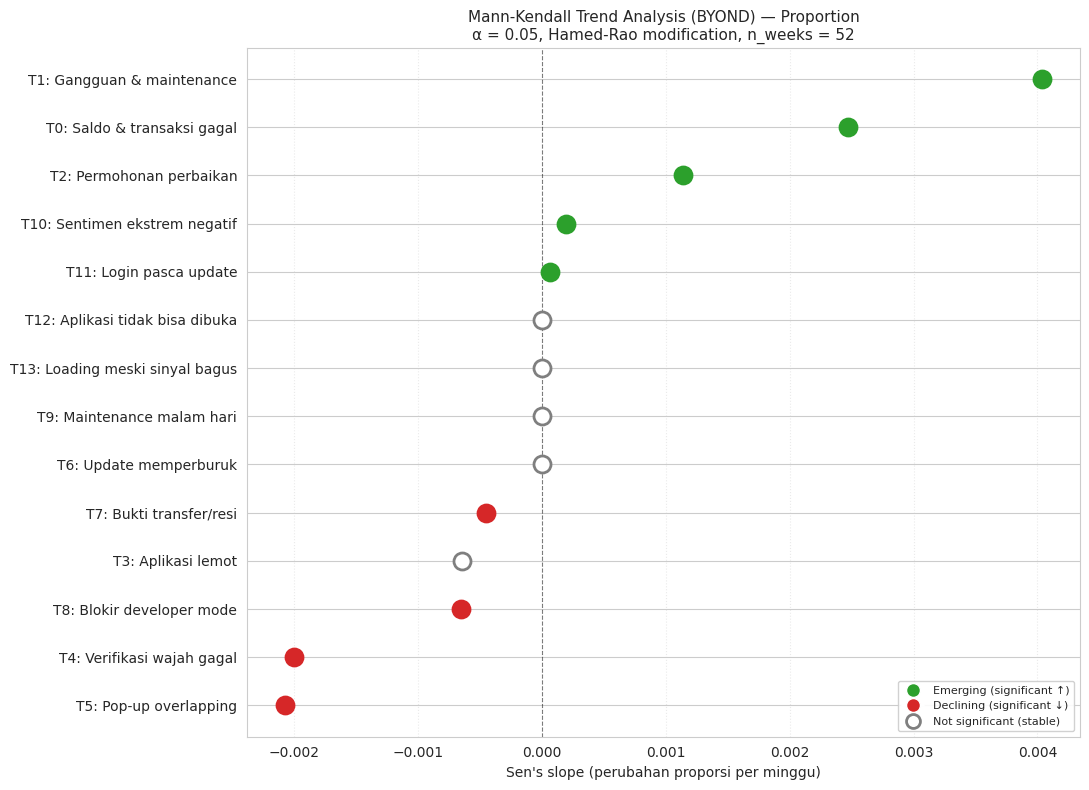

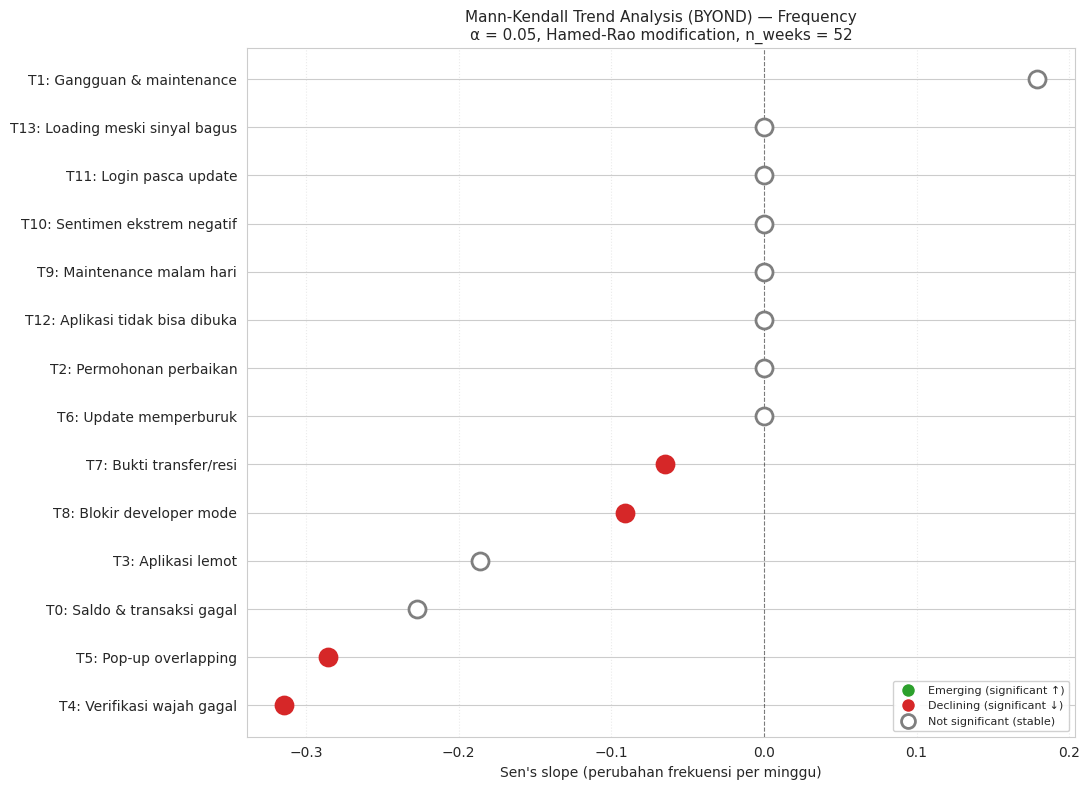


✓ Forest plots saved:
  outputs/figures/byond/10_mk_forest_proportion.png  (BAB 4 main)
  outputs/figures/byond/10_mk_forest_frequency.png   (supplementary)


In [70]:
# --- 10.4 Forest plot Sen's slope (BAB 4 main statistical figure) ---
# CRITICAL BUG WARNING (dari handoff):
# plot_trend_summary() pakai kolom 'Classification' untuk color mapping.
# Default 'Classification' = berdasarkan RAW p-value (NOT FDR-corrected).
# Untuk konsistensi dengan reporting, kita override 'Classification' dengan 
# 'Classification_FDR' SEBELUM pass ke plot function.

from utils.trend_analysis import plot_trend_summary
from pathlib import Path

FIG_DIR_BYOND = Path("outputs/figures/byond")

# --- Prep proportion results untuk plot ---
mk_results_prop_for_plot = mk_results_prop.copy()
mk_results_prop_for_plot['Classification'] = mk_results_prop_for_plot['Classification_FDR']
mk_results_prop_for_plot['Significant'] = mk_results_prop_for_plot['Significant_FDR']

# --- Prep frequency results untuk plot ---
mk_results_freq_for_plot = mk_results_freq.copy()
mk_results_freq_for_plot['Classification'] = mk_results_freq_for_plot['Classification_FDR']
mk_results_freq_for_plot['Significant'] = mk_results_freq_for_plot['Significant_FDR']

# --- Plot proportion (PRIMARY, BAB 4) ---
fig_prop = plot_trend_summary(
    mk_results=mk_results_prop_for_plot,
    fig_dir=FIG_DIR_BYOND,
    app_name=APP_NAME,
    series_type='proportion',
    alpha=ALPHA,
    figsize=(11, 8),
    save=True,
)

# --- Plot frequency (SUPPLEMENTARY) ---
fig_freq = plot_trend_summary(
    mk_results=mk_results_freq_for_plot,
    fig_dir=FIG_DIR_BYOND,
    app_name=APP_NAME,
    series_type='frequency',
    alpha=ALPHA,
    figsize=(11, 8),
    save=True,
)

import matplotlib.pyplot as plt
plt.show()

print("\n✓ Forest plots saved:")
print(f"  outputs/figures/byond/10_mk_forest_proportion.png  (BAB 4 main)")
print(f"  outputs/figures/byond/10_mk_forest_frequency.png   (supplementary)")

In [ ]:
# Forest plot: proportion (FDR-corrected)
mk_results_prop_for_plot = mk_results_prop.copy()
mk_results_prop_for_plot['Classification'] = mk_results_prop['Classification_FDR']
mk_results_prop_for_plot['Significant'] = mk_results_prop['Significant_FDR']

fig_prop = plot_trend_summary(
    mk_results=mk_results_prop_for_plot,
    fig_dir=FIG_DIR,
    app_name='byond',
    series_type='proportion',
    alpha=0.05,
)
plt.show()

In [ ]:
# Forest plot: frequency (FDR-corrected)
mk_results_freq_for_plot = mk_results_freq.copy()
mk_results_freq_for_plot['Classification'] = mk_results_freq['Classification_FDR']
mk_results_freq_for_plot['Significant'] = mk_results_freq['Significant_FDR']

fig_freq = plot_trend_summary(
    mk_results=mk_results_freq_for_plot,
    fig_dir=FIG_DIR,
    app_name='byond',
    series_type='frequency',
    alpha=0.05,
)
plt.show()

### 10.8 Significant trend lines

Small multiples lineplot khusus topic significant — overlay Sen's slope dashed line untuk visualize magnitude.

✓ Saved: outputs\figures\byond\10_mk_significant_lines_proportion.png


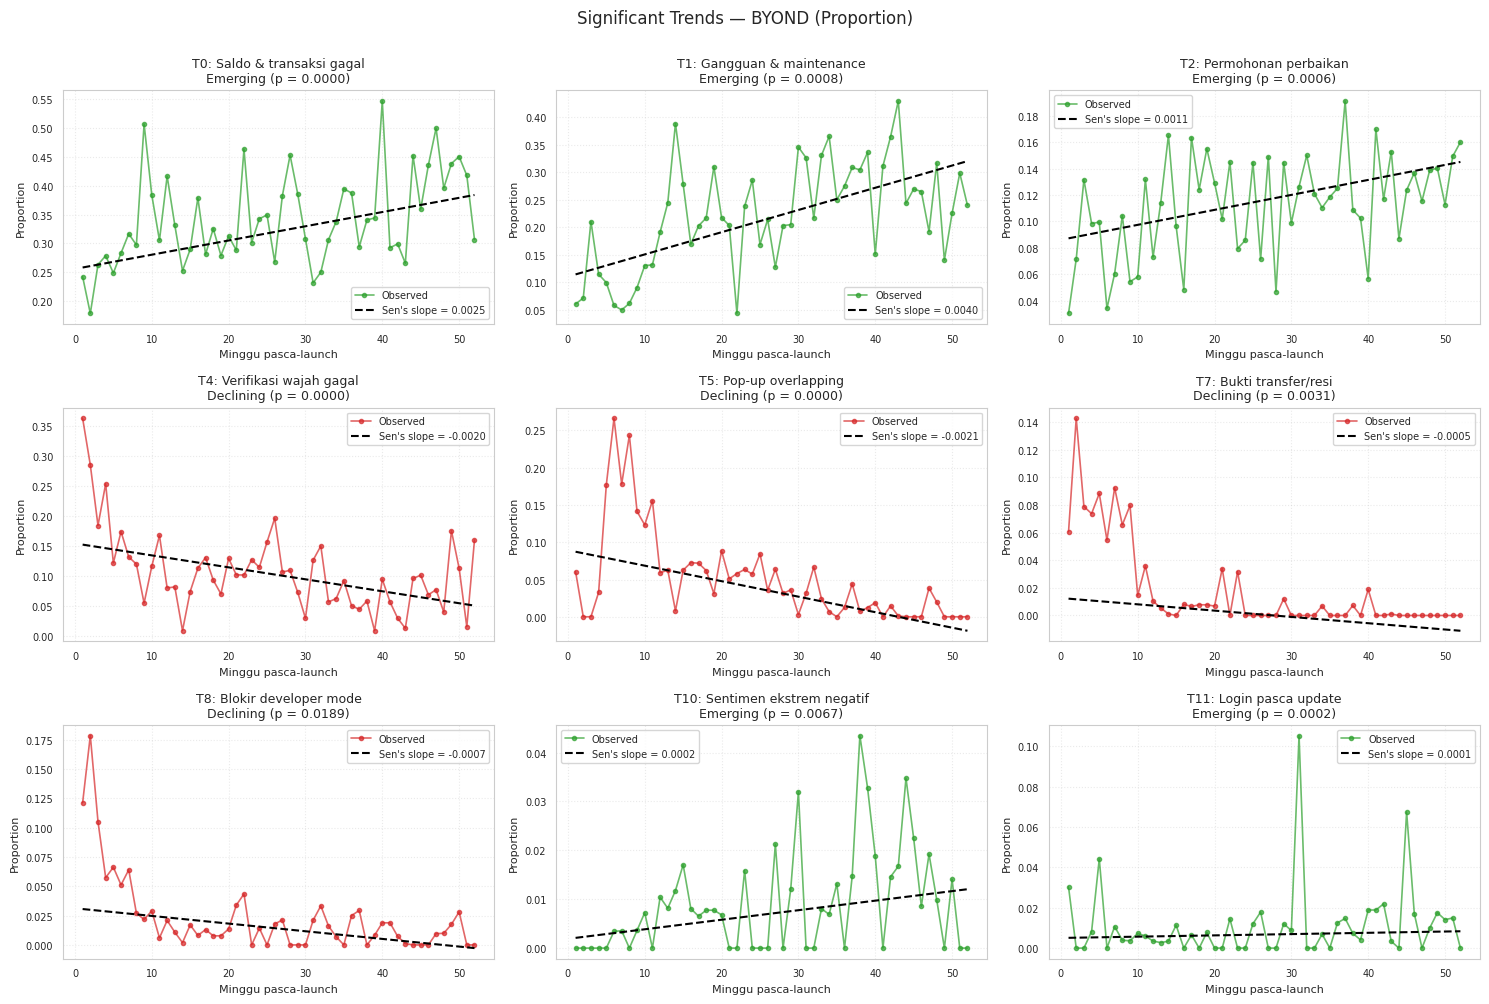


✓ Significant trends lineplot saved
  Total significant topics (proportion): 9
  Emerging: 5
  Declining: 4
  File: outputs/figures/byond/10_mk_significant_lines_proportion.png


In [73]:
# --- 10.5 Lineplot significant trends (small multiples) ---
# Visualize trend yang significant post-FDR. 
# Layout: 1 panel per significant topic, plot weekly proportion + Sen's slope line.
# Hanya plot proportion (primary analysis) — frequency lineplot redundant given 
# similar pattern di consistent topics dan signal lebih jelas di proportion.

from utils.trend_analysis import plot_significant_trends_lines

# CRITICAL: pakai versi *_for_plot supaya filter Significant pakai FDR-corrected,
# bukan raw p-value (sama seperti fix di forest plot).

fig_sig_lines = plot_significant_trends_lines(
    series_df=prop_byond,
    mk_results=mk_results_prop_for_plot,   # already has Significant=Significant_FDR
    topic_labels=topic_labels_byond,
    fig_dir=FIG_DIR_BYOND,
    app_name=APP_NAME,
    series_type='proportion',
    figsize=(15, 10),
    save=True,
)

import matplotlib.pyplot as plt
plt.show()

# Expected: 9 panels (5 emerging + 4 declining)
n_sig = mk_results_prop_for_plot['Significant'].sum()
print(f"\n✓ Significant trends lineplot saved")
print(f"  Total significant topics (proportion): {n_sig}")
print(f"  Emerging: {(mk_results_prop_for_plot['Classification_FDR'] == 'emerging').sum()}")
print(f"  Declining: {(mk_results_prop_for_plot['Classification_FDR'] == 'declining').sum()}")
print(f"  File: outputs/figures/byond/10_mk_significant_lines_proportion.png")

In [ ]:
# Lineplot: proportion (significant only)
fig_sig_prop = plot_significant_trends_lines(
    series_df=weekly_series['proportion'],
    mk_results=mk_results_prop_for_plot,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name='byond',
    series_type='proportion',
)
plt.show()

In [ ]:
# Lineplot: frequency (significant only)
fig_sig_freq = plot_significant_trends_lines(
    series_df=weekly_series['frequency'],
    mk_results=mk_results_freq_for_plot,
    topic_labels=TOPIC_LABELS_BYOND,
    fig_dir=FIG_DIR,
    app_name='byond',
    series_type='frequency',
)
plt.show()

## Section 10.5 — Numerical Edge Case Check (T11-style anomali)

🔴 **Decision point:** Check apakah ada anomali serupa T11 di BYOND.

**Anomali T11 di wondr:** Topic dengan `Sen_slope ≈ 0` tapi MK test signifikan declining/emerging — numerical edge case dari banyak weeks bernilai 0/1, membuat median pairwise slope = 0 padahal S statistic ada nilainya.

**Method (sama wondr):**
1. Flag topic dengan `|Sen_slope| < EPSILON AND Significant_FDR == True`
2. EPSILON = 1e-6 — robust terhadap floating point noise
3. Override classification ke `'Stable (practically)'` di `Classification_FDR_final` column

**Cross-check kedua series:**
- Frequency series — paling rentan anomali (banyak zero-week di topic small N)
- Proportion series — biasanya clean

**Possible outcome:**
- Tidak ada anomali → skip override, tapi **tetep run cell ini** untuk dokumentasi
- Ada anomali — apply fix sama dengan wondr

🔍 BYOND corpus 2x lebih besar → topic small N kemungkinan lebih sedikit → anomali ini mungkin gak muncul.

### 10.5.1 Flag practically_stable di frequency series

In [ ]:
# Re-load MK frequency results
df_mk_freq = pd.read_csv(TABLE_DIR / "byond_mk_frequency.csv")

# Flag practically stable: Sen_slope ≈ 0 AND significant
EPSILON = 1e-6
df_mk_freq['Practically_Stable'] = (
    (df_mk_freq['Sen_slope'].abs() < EPSILON) & 
    (df_mk_freq['Significant_FDR'] == True)
)

# Override classification: kalau practically stable → "Stable (practically)"
df_mk_freq['Classification_FDR_final'] = df_mk_freq.apply(
    lambda row: 'Stable (practically)' if row['Practically_Stable'] else row['Classification_FDR'],
    axis=1
)

# Inspect
n_flagged = df_mk_freq['Practically_Stable'].sum()
print(f"Topics flagged sebagai practically stable: {n_flagged}")
print(f"\nFlagged topics:")
print(df_mk_freq[df_mk_freq['Practically_Stable']][
    ['Topic', 'Label', 'Sen_slope', 'MK_p_value_adj', 'Classification_FDR', 'Classification_FDR_final']
].to_string(index=False))

print(f"\nFinal classification distribution (frequency):")
print(df_mk_freq['Classification_FDR_final'].value_counts())

### 10.5.2 Backup + save updated CSV

In [ ]:
import shutil

# Backup pre-fix version
shutil.copy(
    TABLE_DIR / "byond_mk_frequency.csv",
    TABLE_DIR / "byond_mk_frequency_pre_t11_fix.csv"
)

# Save updated version (overwrite)
df_mk_freq.to_csv(TABLE_DIR / "byond_mk_frequency.csv", index=False)
print("✓ Saved: outputs/tables/byond_mk_frequency.csv (T11 anomali handled)")
print("✓ Backup: outputs/tables/byond_mk_frequency_pre_t11_fix.csv")

### 10.5.3 Cross-check: anomali di proportion series?

In [ ]:
df_mk_prop = pd.read_csv(TABLE_DIR / "byond_mk_proportion.csv")
df_mk_prop['Practically_Stable'] = (
    (df_mk_prop['Sen_slope'].abs() < EPSILON) & 
    (df_mk_prop['Significant_FDR'] == True)
)

n_flagged_prop = df_mk_prop['Practically_Stable'].sum()
print(f"Proportion series — topics flagged: {n_flagged_prop}")
if n_flagged_prop > 0:
    print(df_mk_prop[df_mk_prop['Practically_Stable']][
        ['Topic', 'Label', 'Sen_slope', 'MK_p_value_adj', 'Classification_FDR']
    ])
else:
    print("✓ Proportion series clean, no anomali.")
    print("  Konsisten dengan finding handoff v9 (T11 anomali only di frequency series).")

## Pipeline Status & Next Steps

### BYOND coding ⏳ IN PROGRESS

Notebook ini akan di-eksekusi sequential. Setiap section ada decision points yang bertanda 🔴 — jangan blind run.

**Expected outputs (after full run):**

- **Model:** `data/models/byond_phase_c/` (TBD topics, c_v=TBD, c_npmi=TBD)
- **DTM:** `data/processed/byond_topics_over_time.pkl`
- **12 figures:** `outputs/figures/byond/`
- **~9 tables:** `outputs/tables/byond_*.csv`

### After BYOND: Comparative analysis wondr vs BYOND

Setelah BYOND lengkap, integrate semua finding wondr + BYOND untuk comparative analysis di BAB 4. Foundation: tabel topic landscape, pattern temporal per app, cross-app theme, comparative reliability metrics.

### Outstanding (defer ke phase BAB 4 drafting)

- Update `outputs/draft_section9_findings_byond.md` — masih threshold lama
- FDR-BH metodologi paragraf untuk BAB 3
- T11 anomali narrative untuk BAB 4
- Integrated wondr findings narrative untuk BAB 4
- Cosmetic: capitalization inconsistency `'stable'` vs `'Stable (practically)'` di frequency CSV